<a href="https://colab.research.google.com/github/aparikh6-droid/temp/blob/main/BUFN400_bhw01_CRSP_10_12_individual_stocks_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BUFN400: Big Homework 1: Introduction to Financial Analysis Using Pandas and WRDS CRSP Data

## By Albert S. (Pete) Kyle

### August 28, 2026

**You should read this notebook carefully by studying each line of code to understand what it does computationally and why it is useful financially. There are homework questions at the end of this notebook. You should answer the homework questions by adding cells as necessary, then submit an HTML or PDF version of your homework to Canvas.**

**If you are not proficient in Python (especially the Pandas package), this homework will take a lot of time to complete properly.**

This notebook shows how to use the Python package Pandas to read, clean, and then examine datasets downloaded from WRDS.

In typical applications, the Python package Pandas is used for manipulating data. The Python package Numpy is used for numerical calculations, especially when numerical efficiency is important.

When performing data analysis using Python, it is almost always inefficient (slow) to write interpreted Python loops of the form `for i in range(10**6): Do_something()`. Both Pandas and Numpy have efficient functions which make it mostly (but not always) unnecessary to write these inefficient Python loops.

Students should become familiar enough with Pandas to use the approach illustrated here on other datasets, regardless of size or complexity.


### CRSP Data

The example considered in this notebook is the  **CRSP Daily Stock file**.

**CRSP** is a popular, standard data source for financial information. It is widely used by academia, business, and government.  It has a reputation for excellent accuracy and comprehensive coverage. The University of Maryland subscribes to some of the CRSP data but not all of it. Financial data is often proprietary, and subscriptions are often expensive.

You should read each cell carefully, study each code cell carefully, and run all of the code cells on your own  computer. The functions used in the various code cells will be used throughout this course, including on the next homework and future homeworks! The Python (Pandas) usage illustrated here is typical of what you might do in a summer internship working for a financial firm.

**Please let me know if you see errors or things which are unclear, so that I can post a revised version.**

### Pandas DataFrames

Pandas stores data as a dataframe (`pd.DataFrame`), a rectangular format which we can think of as columns of data, each of the same length. In principle, all of the data in one column must have the same `dtype` (e.g., `float64` or `int64` or string). Different columns may have different dtypes. In addition to the rectangle of data, a dataframe also has an index of names for each column and another index for each row. It is useful to think of a Panda's dataframe as a Python dictionary with additional structure enforcing consistency in lengths of columns, convenient indexing for both rows and columns, and numerous functions for data manipulation. This additional structure is precisely what is typically needed to play with financial datasets.

 A column of numbers in a Pandas dataframe can be thought of as a wrapper around a Numpy array. Getting started with Pandas can be confusing because the dtypes needed for numerical efficiency differ from the dtypes needed for data manipulation. This has led to changes in Pandas over the years. Two recent changes, which may be sources of confusion, are the following:

1. For data analysis, it is useful to have keep track of missing values and also make distinctions between values which are `None`, missing, or poorly defined. To handle this,  Pandas has recently introduced a "nullable integer" dtype, which can add functionality for missing data to Numpy's integer dtypes, which do not allow missing data. (Under the old approach, adding a missing value to a column of integers forced conversion of the column to a float type, which is often inconvenient and confusing.)

2. Pandas has traditionally had a clunky and inefficient way of handling columns of string data. Strings are stored as dtype `object`, which is a catchall for arbitrary or inconsistent dtypes. The `object` dtype handles strings flexibly but inefficiently. Pandas is in the process of replacing this inefficient `object` dtype with Pyarrow string dtypes, which are more efficient.

Pandas does have some limitations:

1. Pandas is inconvenient for storing matrices since a two-dimensional array does not easily fit into one column of data.

2. If numerically intensive analysis is needed, it is often a good idea to convert data from Pandas to Numpy. This may be efficient, since the data need not always be copied.

3. If numpy is not efficient enough, I recommend the Python package **Numba** for computations on the cpu (especially useful when inefficient Python loops would otherwise be needed),  the packages **Pytorch** or **Jax** for computations on a gpu, the Python package **Dask** (or **Ray** or **Modin** or **Vaex**) for multiprocessing of datasets too large to fit into memory, and the Python packages **Cupy** and **Cudf** in the **RAPIDS** family for Numpy-like and Pandas-like computations on a gpu. Some gpu-friendly packages, such as Jax and Cudf, only work under Linux. I use **Windows Subsystem for Linux** (**WSL**) for these packages, which works well.  Using a gpu, I can speed up my research on large datasets by factors like 20X relative to using 6-20 cpu cores on my laptop.  In general, Python works better with Linux than Windows, especially when gpus are involved.



### Download data from the WRDS website

Go to the WRDS website https://wrds-www.wharton.upenn.edu/.

You will first need to create a student account to download data for BUFN400. As you follow the instructions for creating an account, you should be asked for a code for the course. This code should be kept confidential among students taking the course. I will supply this code separately since this homework assignment might become public.

After creating your account, log in using the credentials for BUFN400 (supplied separately), and find the CRSP daily stock files at

Home / Get Data / CRSP / Annual Update / Stock - Version 2 (CIZ) / Daily Stock File

which is here:

https://wrds-www.wharton.upenn.edu/pages/get-data/center-research-security-prices-crsp/annual-update/stock-version-2/daily-stock-file/

The term "Annual Update" refers to the fact that the University subscription is updated annually. Therefore, if you are downloading data in September 2026, the most recent data will be for December 31, 2025. Data for 2026 will become available well after the start of 2027.

There are five different tabs: Query Form, Variable Descriptions, Manuals and Overviews, Knowledge Base, Data Preview.

To download data, use the tab "Query Form". The other tabs containg important information which describes what the data mean.

Students in BUFN400 are required to download data using the "Query Form" web interface. Follow steps 1--4 as follows:

1. Choose the beginning date 1925-12-31 (the date when the data series begins) and the ending date 2025-12-31 (the most recent annual update).

2. Enter the following list of **ticker symbols** in the cell identified as "Search Name or Ticker": "GM IBM MSFT AAPL META GOOG TSLA INTC BAC BRK". These ticker symbols correspond to the current well-known companies we call General Motors, IBM, Microsoft, Apple, Meta (=Facebook), Google, Tesla, Intel, Bank of America, and Berkshire Hathaway. If you are particularly interested in some other companies, feel free to add them to the list as well.

3. Click on  the checked "All" box to move the names of all of the data series from the left side of the page ("Select", i.e., not selected yet) to the right side ("Selected", i.e., already selected for download).

4. Select the following options: "comma delimited text (*.csv)", "gzip (*.gz)", and "YYYY-MM-DD (e.g., 1984-07-25)". The `*.csv` format is used frequently in data analysis because it is easily read by humans, widely supported, and often compresses well. The `gzip` format is a convenient way to compress the data. The `YYYY-MM-DD` format is a convenient way to represent dates. Pandas handles many different data formats, but it handles `csv`, `gzip`, and `YYYY-MM-DD` especially efficiently and conveniently. (Feel free to experiment by checking different boxes to see what happens. Presumably, uncompressed data will be larger on disk and will probably download from the WRDS website  more slowly, but does it load from disk into memory faster? Considerations like this might be relevant when dealing with very large datasets.)

Then click "Submit Form". It may take WRDS several minutes to prepare your data, after which you may click a button to download it to your computer. (In my case, it took WRDS about five minutes to run the query, and the compressed dataset was about 7 MB.)

If you like, you might download the entire dataset, but make sure you have enough storage space first.  The entire dataset is likely 1000x or more larger than what is required for this assignment. If you would like to look at a smaller dataset with an exhaustive list of stocks, you might try downloading the monthly CRSP dataset.

WRDS gives the dataset a name consisting of random characters. I suggest renaming your dataset to something easy to identify.

**As we shall see later in this assignment, ticker symbols may not be the best way to identify companies. Nevertheless, it is instructive to use ticker symbols (at least once) to see what we learn about finance and to see what kinds of issues are raised by using ticker symbols.**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import datetime
import timeit
import os
import sys

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 100)

print(f"timestamp = {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print('Python version ' + sys.version)
print('Pandas version ' + pd.__version__)
print('NumPy version ' + np.__version__)
print('matplotlib version ' + matplotlib.__version__)

t_begin = timeit.default_timer()

timestamp = 2026-09-09 17:01:34
Python version 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Pandas version 2.2.3
NumPy version 2.1.3
matplotlib version 3.10.0


### Use `pd.read_csv(...)` to load data

Many datasets can easily be read in one line with the function `pd.read_csv(...)`.  In other cases, reading in data properly takes some effort because the names and dtypes of columns are not accurately known in advance (in which case  data dictionaries are important!). Typical problems include the following:

1. Documentation for columns may be missing or incorrect.

2. The date formats may non-standard and different from one another.

3. The data formats may not be what is needed. For example, the data may be of type `float` when type `int` is needed.

4. It is not obvious whether certain columns should have dtype of `int`, `float`, `string`, `category`, or `datetime`.

These types of considerations are commonplace for all types of analysis - financial or otherwise. Make sure you understand what your data is saying before gleaning any inferences from it!

A useful strategy is to try to read the data with a one-line version of `pd.read_csv(...)`, then do some preliminary data exploration to see whether further refinement is needed.

It is also typical to time specific code snippets to explore ways to improve code efficiency.

So let's try to read the data in one line and time it at the same time:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dir_path = r"/content/drive/MyDrive/BUFN400/"
file_name = "BH1StockData.csv"

# NB: I recommend os.path.join(...) over string addition.
# os.path.join(...) remembers to place the '/' character correctly and works better across different operating systems.
file_path = os.path.join(dir_path, file_name)
# file_path = dir_path + '/' + file_name

t0 = timeit.default_timer()
df = pd.read_csv(file_path)  # Read data in one simple line of code! Pandas guesses what dtypes you want
# df = pd.read_csv(file_path, parse_dates=True)  # Does not actually parse dates
# df = pd.read_csv(file_path, parse_dates=True, low_memory=False)  # Avoids DtypeWarning
# df = pd.read_csv(file_path, dtype='string')  # Read everyting into strings for further processing
dt = timeit.default_timer() - t0

print(f"Reading the data took {dt} seconds.")

/tmp/ipykernel_824/3792585793.py:10: DtypeWarning: Columns (6,7,8,9,12,15,22,50,70,72,74,75,76,77,78,79,80,84,85,86) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)  # Read data in one simple line of code! Pandas guesses what dtypes you want


Reading the data took 3.410599732999998 seconds.


In [ ]:
df.head()

,PERMNO,SecInfoStartDt,SecInfoEndDt,SecurityBegDt,SecurityEndDt,SecurityHdrFlg,HdrCUSIP,HdrCUSIP9,CUSIP,CUSIP9,PrimaryExch,ConditionalType,ExchangeTier,TradingStatusFlg,SecurityNm,ShareClass,USIncFlg,IssuerType,SecurityType,SecuritySubType,ShareType,SecurityActiveFlg,DelActionType,DelStatusType,DelReasonType,DelPaymentType,Ticker,TradingSymbol,PERMCO,SICCD,NAICS,ICBIndustry,NASDCompno,NASDIssuno,IssuerNm,YYYYMMDD,DlyCalDt,DlyDelFlg,DlyPrc,DlyPrcFlg,DlyCap,DlyCapFlg,DlyPrevPrc,DlyPrevPrcFlg,DlyPrevDt,DlyPrevCap,DlyPrevCapFlg,DlyRet,DlyRetx,DlyRetI,DlyRetMissFlg,DlyRetDurFlg,DlyOrdDivAmt,DlyNonOrdDivAmt,DlyFacPrc,DlyDistRetFlg,DlyVol,DlyClose,DlyLow,DlyHigh,DlyBid,DlyAsk,DlyOpen,DlyNumTrd,DlyMMCnt,DlyPrcVol,ShrStartDt,ShrEndDt,ShrOut,ShrSource,ShrFacType,ShrAdrFlg,DisExDt,DisSeqNbr,DisOrdinaryFlg,DisType,DisFreqType,DisPaymentType,DisDetailType,DisTaxType,DisOrigCurType,DisDivAmt,DisFacPr,DisFacShr,DisDeclareDt,DisRecordDt,DisPayDt,DisPERMNO,DisPERMCO,vwretd,vwretx,ewretd,ewretx,sprtrn
0,10107,1986-03-13,2004-06-09,1986-03-13,2025-12-31,N,59491810,594918104,59491810,594918104,Q,RW,NMS,A,MICROSOFT CORP; COM NONE; CONS,NaN,Y,CORP,EQTY,COM,NS,Y,NaN,UNAV,NACT,UNAV,MSFT,MSFT,8048,7370,0,NOAVAIL,60008001,10539,MICROSOFT CORP,19860313,1986-03-13,N,28.00,TR,714532.00,BP,NaN,NS,NaN,NaN,MP,NaN,NaN,NaN,NS,MR,0.0,0.0,1.0,NO,3597701.0,28.00,25.5,29.25,27.75,28.00,NaN,3410.0,33.0,100735628.0,1986-03-13,1986-03-30,25519,OBS,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002131,0.002104,0.001268,0.001247,0.002795
1,10107,1986-03-13,2004-06-09,1986-03-13,2025-12-31,N,59491810,594918104,59491810,594918104,Q,RW,NMS,A,MICROSOFT CORP; COM NONE; CONS,NaN,Y,CORP,EQTY,COM,NS,Y,NaN,UNAV,NACT,UNAV,MSFT,MSFT,8048,7370,0,NOAVAIL,60008001,10539,MICROSOFT CORP,19860314,1986-03-14,N,29.00,TR,740051.00,BP,28.00,TR,1986-03-13,714532.00,PB,0.035714,0.035714,0.0,NaN,D1,0.0,0.0,1.0,NO,1077151.0,29.00,28.0,29.50,29.00,29.25,NaN,1809.0,32.0,31237379.0,1986-03-13,1986-03-30,25519,OBS,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010278,0.010240,0.005065,0.004965,0.014409
2,10107,1986-03-13,2004-06-09,1986-03-13,2025-12-31,N,59491810,594918104,59491810,594918104,Q,RW,NMS,A,MICROSOFT CORP; COM NONE; CONS,NaN,Y,CORP,EQTY,COM,NS,Y,NaN,UNAV,NACT,UNAV,MSFT,MSFT,8048,7370,0,NOAVAIL,60008001,10539,MICROSOFT CORP,19860317,1986-03-17,N,29.50,TR,752810.50,BP,29.00,TR,1986-03-14,740051.00,PB,0.017241,0.017241,0.0,NaN,D3,0.0,0.0,1.0,NO,465719.0,29.50,29.0,29.75,29.50,29.75,NaN,772.0,27.0,13738710.5,1986-03-13,1986-03-30,25519,OBS,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.007085,-0.007120,-0.004117,-0.004179,-0.007948
3,10107,1986-03-13,2004-06-09,1986-03-13,2025-12-31,N,59491810,594918104,59491810,594918104,Q,RW,NMS,A,MICROSOFT CORP; COM NONE; CONS,NaN,Y,CORP,EQTY,COM,NS,Y,NaN,UNAV,NACT,UNAV,MSFT,MSFT,8048,7370,0,NOAVAIL,60008001,10539,MICROSOFT CORP,19860318,1986-03-18,N,28.75,TR,733671.25,BP,29.50,TR,1986-03-17,752810.50,PB,-0.025424,-0.025424,0.0,NaN,D1,0.0,0.0,1.0,NO,232056.0,28.75,28.5,29.75,28.75,29.00,NaN,484.0,25.0,6671610.0,1986-03-13,1986-03-30,25519,OBS,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004968,0.004894,0.003313,0.003278,0.004730
4,10107,1986-03-13,2004-06-09,1986-03-13,2025-12-31,N,59491810,594918104,59491810,594918104,Q,RW,NMS,A,MICROSOFT CORP; COM NONE; CONS,NaN,Y,CORP,EQTY,COM,NS,Y,NaN,UNAV,NACT,UNAV,MSFT,MSFT,8048,7370,0,NOAVAIL,60008001,10539,MICROSOFT CORP,19860319,1986-03-19,N,28.25,TR,720911.75,BP,28.75,TR,1986-03-18,733671.25,PB,-0.017391,-0.017391,0.0,NaN,D1,0.0,0.0,1.0,NO,168024.0,28.25,28.0,29.00,28.00,28.25,NaN,377.0,24.0,4746678.0,1986-03-13,1986-03-30,25519,OBS,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.001350,-0.001372,0.000262,0.000241,-0.000763



I received a warning like the warning:

"DtypeWarning: Columns (6,7,8,9,12,15,22,27,50,70,76,80) have mixed types. Specify dtype option on import or set low_memory=False."

This warning is typical. As we explore the data further, we will likely find out why we got the warning.




#### Basic information

Let's get some basic information about the dataframe `df`.

To do so, I will illustrate some commonly used Python and Pandas functions. You should become familiar with all of these functions in order to be proficient with Pandas.

In [ ]:
print(f"Number of rows: {len(df)=}\n")
print(f"Number of columns: {len(df.columns)=}\n")
print(f"Names of columns: {df.columns=}\n")
print(f"Names of columns with warning: {df.columns[[6,7,8,9,12,15,22,27,50,70,76,80]]=}\n")

Number of rows: len(df)=115051

Number of columns: len(df.columns)=94

Names of columns: df.columns=Index(['PERMNO', 'SecInfoStartDt', 'SecInfoEndDt', 'SecurityBegDt', 'SecurityEndDt',
       'SecurityHdrFlg', 'HdrCUSIP', 'HdrCUSIP9', 'CUSIP', 'CUSIP9', 'PrimaryExch',
       'ConditionalType', 'ExchangeTier', 'TradingStatusFlg', 'SecurityNm', 'ShareClass',
       'USIncFlg', 'IssuerType', 'SecurityType', 'SecuritySubType', 'ShareType',
       'SecurityActiveFlg', 'DelActionType', 'DelStatusType', 'DelReasonType', 'DelPaymentType',
       'Ticker', 'TradingSymbol', 'PERMCO', 'SICCD', 'NAICS', 'ICBIndustry', 'NASDCompno',
       'NASDIssuno', 'IssuerNm', 'YYYYMMDD', 'DlyCalDt', 'DlyDelFlg', 'DlyPrc', 'DlyPrcFlg',
       'DlyCap', 'DlyCapFlg', 'DlyPrevPrc', 'DlyPrevPrcFlg', 'DlyPrevDt', 'DlyPrevCap',
       'DlyPrevCapFlg', 'DlyRet', 'DlyRetx', 'DlyRetI', 'DlyRetMissFlg', 'DlyRetDurFlg',
       'DlyOrdDivAmt', 'DlyNonOrdDivAmt', 'DlyFacPrc', 'DlyDistRetFlg', 'DlyVol', 'DlyClose',
       '

It is useful to display the first several rows of data and the last several rows of data.

In [ ]:
df.head(5)

,PERMNO,SecInfoStartDt,SecInfoEndDt,SecurityBegDt,SecurityEndDt,SecurityHdrFlg,HdrCUSIP,HdrCUSIP9,CUSIP,CUSIP9,PrimaryExch,ConditionalType,ExchangeTier,TradingStatusFlg,SecurityNm,ShareClass,USIncFlg,IssuerType,SecurityType,SecuritySubType,ShareType,SecurityActiveFlg,DelActionType,DelStatusType,DelReasonType,DelPaymentType,Ticker,TradingSymbol,PERMCO,SICCD,NAICS,ICBIndustry,NASDCompno,NASDIssuno,IssuerNm,YYYYMMDD,DlyCalDt,DlyDelFlg,DlyPrc,DlyPrcFlg,DlyCap,DlyCapFlg,DlyPrevPrc,DlyPrevPrcFlg,DlyPrevDt,DlyPrevCap,DlyPrevCapFlg,DlyRet,DlyRetx,DlyRetI,DlyRetMissFlg,DlyRetDurFlg,DlyOrdDivAmt,DlyNonOrdDivAmt,DlyFacPrc,DlyDistRetFlg,DlyVol,DlyClose,DlyLow,DlyHigh,DlyBid,DlyAsk,DlyOpen,DlyNumTrd,DlyMMCnt,DlyPrcVol,ShrStartDt,ShrEndDt,ShrOut,ShrSource,ShrFacType,ShrAdrFlg,DisExDt,DisSeqNbr,DisOrdinaryFlg,DisType,DisFreqType,DisPaymentType,DisDetailType,DisTaxType,DisOrigCurType,DisDivAmt,DisFacPr,DisFacShr,DisDeclareDt,DisRecordDt,DisPayDt,DisPERMNO,DisPERMCO,vwretd,vwretx,ewretd,ewretx,sprtrn
0,10107,1986-03-13,2004-06-09,1986-03-13,2025-12-31,N,59491810,594918104,59491810,594918104,Q,RW,NMS,A,MICROSOFT CORP; COM NONE; CONS,NaN,Y,CORP,EQTY,COM,NS,Y,NaN,UNAV,NACT,UNAV,MSFT,MSFT,8048,7370,0,NOAVAIL,60008001,10539,MICROSOFT CORP,19860313,1986-03-13,N,28.00,TR,714532.00,BP,NaN,NS,NaN,NaN,MP,NaN,NaN,NaN,NS,MR,0.0,0.0,1.0,NO,3597701.0,28.00,25.5,29.25,27.75,28.00,NaN,3410.0,33.0,100735628.0,1986-03-13,1986-03-30,25519,OBS,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002131,0.002104,0.001268,0.001247,0.002795
1,10107,1986-03-13,2004-06-09,1986-03-13,2025-12-31,N,59491810,594918104,59491810,594918104,Q,RW,NMS,A,MICROSOFT CORP; COM NONE; CONS,NaN,Y,CORP,EQTY,COM,NS,Y,NaN,UNAV,NACT,UNAV,MSFT,MSFT,8048,7370,0,NOAVAIL,60008001,10539,MICROSOFT CORP,19860314,1986-03-14,N,29.00,TR,740051.00,BP,28.00,TR,1986-03-13,714532.00,PB,0.035714,0.035714,0.0,NaN,D1,0.0,0.0,1.0,NO,1077151.0,29.00,28.0,29.50,29.00,29.25,NaN,1809.0,32.0,31237379.0,1986-03-13,1986-03-30,25519,OBS,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010278,0.010240,0.005065,0.004965,0.014409
2,10107,1986-03-13,2004-06-09,1986-03-13,2025-12-31,N,59491810,594918104,59491810,594918104,Q,RW,NMS,A,MICROSOFT CORP; COM NONE; CONS,NaN,Y,CORP,EQTY,COM,NS,Y,NaN,UNAV,NACT,UNAV,MSFT,MSFT,8048,7370,0,NOAVAIL,60008001,10539,MICROSOFT CORP,19860317,1986-03-17,N,29.50,TR,752810.50,BP,29.00,TR,1986-03-14,740051.00,PB,0.017241,0.017241,0.0,NaN,D3,0.0,0.0,1.0,NO,465719.0,29.50,29.0,29.75,29.50,29.75,NaN,772.0,27.0,13738710.5,1986-03-13,1986-03-30,25519,OBS,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.007085,-0.007120,-0.004117,-0.004179,-0.007948
3,10107,1986-03-13,2004-06-09,1986-03-13,2025-12-31,N,59491810,594918104,59491810,594918104,Q,RW,NMS,A,MICROSOFT CORP; COM NONE; CONS,NaN,Y,CORP,EQTY,COM,NS,Y,NaN,UNAV,NACT,UNAV,MSFT,MSFT,8048,7370,0,NOAVAIL,60008001,10539,MICROSOFT CORP,19860318,1986-03-18,N,28.75,TR,733671.25,BP,29.50,TR,1986-03-17,752810.50,PB,-0.025424,-0.025424,0.0,NaN,D1,0.0,0.0,1.0,NO,232056.0,28.75,28.5,29.75,28.75,29.00,NaN,484.0,25.0,6671610.0,1986-03-13,1986-03-30,25519,OBS,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004968,0.004894,0.003313,0.003278,0.004730
4,10107,1986-03-13,2004-06-09,1986-03-13,2025-12-31,N,59491810,594918104,59491810,594918104,Q,RW,NMS,A,MICROSOFT CORP; COM NONE; CONS,NaN,Y,CORP,EQTY,COM,NS,Y,NaN,UNAV,NACT,UNAV,MSFT,MSFT,8048,7370,0,NOAVAIL,60008001,10539,MICROSOFT CORP,19860319,1986-03-19,N,28.25,TR,720911.75,BP,28.75,TR,1986-03-18,733671.25,PB,-0.017391,-0.017391,0.0,NaN,D1,0.0,0.0,1.0,NO,168024.0,28.25,28.0,29.00,28.00,28.25,NaN,377.0,24.0,4746678.0,1986-03-13,1986-03-30,25519,OBS,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.001350,-0.001372,0.000262,0.000241,-0.000763


In [ ]:
df.tail(4)

,PERMNO,SecInfoStartDt,SecInfoEndDt,SecurityBegDt,SecurityEndDt,SecurityHdrFlg,HdrCUSIP,HdrCUSIP9,CUSIP,CUSIP9,PrimaryExch,ConditionalType,ExchangeTier,TradingStatusFlg,SecurityNm,ShareClass,USIncFlg,IssuerType,SecurityType,SecuritySubType,ShareType,SecurityActiveFlg,DelActionType,DelStatusType,DelReasonType,DelPaymentType,Ticker,TradingSymbol,PERMCO,SICCD,NAICS,ICBIndustry,NASDCompno,NASDIssuno,IssuerNm,YYYYMMDD,DlyCalDt,DlyDelFlg,DlyPrc,DlyPrcFlg,DlyCap,DlyCapFlg,DlyPrevPrc,DlyPrevPrcFlg,DlyPrevDt,DlyPrevCap,DlyPrevCapFlg,DlyRet,DlyRetx,DlyRetI,DlyRetMissFlg,DlyRetDurFlg,DlyOrdDivAmt,DlyNonOrdDivAmt,DlyFacPrc,DlyDistRetFlg,DlyVol,DlyClose,DlyLow,DlyHigh,DlyBid,DlyAsk,DlyOpen,DlyNumTrd,DlyMMCnt,DlyPrcVol,ShrStartDt,ShrEndDt,ShrOut,ShrSource,ShrFacType,ShrAdrFlg,DisExDt,DisSeqNbr,DisOrdinaryFlg,DisType,DisFreqType,DisPaymentType,DisDetailType,DisTaxType,DisOrigCurType,DisDivAmt,DisFacPr,DisFacShr,DisDeclareDt,DisRecordDt,DisPayDt,DisPERMNO,DisPERMCO,vwretd,vwretx,ewretd,ewretx,sprtrn
115047,93436,2023-10-01,2025-12-31,2010-06-29,2025-12-31,Y,88160R10,88160R101,88160R10,88160R101,Q,RW,Q,A,TESLA INC; COM NONE; CONS,NaN,Y,CORP,EQTY,COM,NS,Y,NaN,UNAV,NACT,UNAV,TSLA,TSLA,53453,3711,336110,NOAVAIL,60069832,66252,TESLA INC,20251226,2025-12-26,N,475.19,TR,1.580396e+09,BP,485.40,TR,2025-12-24,1.614353e+09,PB,-0.021034,-0.021034,0.0,NaN,D2,0.0,0.0,1.0,NO,58470032.0,475.19,473.82,489.09,475.19,475.24,485.23,1306094.0,54.0,2.778437e+10,2025-10-16,2025-12-31,3325819,OBS,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000242,-0.000325,-0.002105,-0.002373,-0.000304
115048,93436,2023-10-01,2025-12-31,2010-06-29,2025-12-31,Y,88160R10,88160R101,88160R10,88160R101,Q,RW,Q,A,TESLA INC; COM NONE; CONS,NaN,Y,CORP,EQTY,COM,NS,Y,NaN,UNAV,NACT,UNAV,TSLA,TSLA,53453,3711,336110,NOAVAIL,60069832,66252,TESLA INC,20251229,2025-12-29,N,459.64,TR,1.528679e+09,BP,475.19,TR,2025-12-26,1.580396e+09,PB,-0.032724,-0.032724,0.0,NaN,D3,0.0,0.0,1.0,NO,65769882.0,459.64,459.00,469.40,459.58,459.65,469.00,1591419.0,54.0,3.023047e+10,2025-10-16,2025-12-31,3325819,OBS,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.004191,-0.004230,-0.008373,-0.008603,-0.003492
115049,93436,2023-10-01,2025-12-31,2010-06-29,2025-12-31,Y,88160R10,88160R101,88160R10,88160R101,Q,RW,Q,A,TESLA INC; COM NONE; CONS,NaN,Y,CORP,EQTY,COM,NS,Y,NaN,UNAV,NACT,UNAV,TSLA,TSLA,53453,3711,336110,NOAVAIL,60069832,66252,TESLA INC,20251230,2025-12-30,N,454.43,TR,1.511352e+09,BP,459.64,TR,2025-12-29,1.528679e+09,PB,-0.011335,-0.011335,0.0,NaN,D1,0.0,0.0,1.0,NO,58669128.0,454.43,453.83,463.12,454.38,454.43,461.09,1296961.0,54.0,2.666101e+10,2025-10-16,2025-12-31,3325819,OBS,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.001550,-0.001576,-0.002831,-0.003547,-0.001376
115050,93436,2023-10-01,2025-12-31,2010-06-29,2025-12-31,Y,88160R10,88160R101,88160R10,88160R101,Q,RW,Q,A,TESLA INC; COM NONE; CONS,NaN,Y,CORP,EQTY,COM,NS,Y,NaN,UNAV,NACT,UNAV,TSLA,TSLA,53453,3711,336110,NOAVAIL,60069832,66252,TESLA INC,20251231,2025-12-31,N,449.72,TR,1.495687e+09,BP,454.43,TR,2025-12-30,1.511352e+09,PB,-0.010365,-0.010365,0.0,NaN,D1,0.0,0.0,1.0,NO,48644113.0,449.72,449.30,456.55,449.55,449.75,456.10,1106022.0,54.0,2.187623e+10,2025-10-16,2025-12-31,3325819,OBS,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.007319,-0.007491,-0.005245,-0.005627,-0.007358


It is also useful to know the dtypes for the columns:

In [ ]:
df.dtypes

,0
PERMNO,int64
SecInfoStartDt,object
SecInfoEndDt,object
SecurityBegDt,object
SecurityEndDt,object
SecurityHdrFlg,object
HdrCUSIP,object
HdrCUSIP9,object
CUSIP,object
CUSIP9,object


There are other simple functions for describing dataframes:

In [ ]:
df.describe()

,PERMNO,PERMCO,SICCD,NAICS,NASDCompno,NASDIssuno,YYYYMMDD,DlyPrc,DlyCap,DlyPrevPrc,DlyPrevCap,DlyRet,DlyRetx,DlyRetI,DlyOrdDivAmt,DlyNonOrdDivAmt,DlyFacPrc,DlyVol,DlyClose,DlyLow,DlyHigh,DlyBid,DlyAsk,DlyOpen,DlyNumTrd,DlyMMCnt,DlyPrcVol,ShrOut,DisSeqNbr,DisDivAmt,DisFacPr,DisFacShr,DisPERMNO,DisPERMCO,vwretd,vwretx,ewretd,ewretx,sprtrn
count,115051.000000,115051.000000,115051.000000,115051.000000,1.150510e+05,115051.000000,1.150510e+05,115041.000000,1.150410e+05,115028.000000,1.150280e+05,115028.000000,115028.000000,115028.000000,115051.000000,115051.0,115051.000000,1.120510e+05,111737.000000,111677.000000,111675.000000,87884.000000,87884.000000,78561.000000,4.438500e+04,45005.000000,1.120510e+05,1.150510e+05,1151.000000,1101.000000,1151.000000,1151.000000,1151.000000,1151.000000,115051.000000,115051.000000,115051.000000,115051.000000,115049.000000
mean,35961.279537,14459.941704,4906.584506,201949.072472,3.950098e+07,7570.901279,2.000368e+07,13893.736035,1.943996e+08,13888.752226,1.942994e+08,0.000792,0.000714,0.000078,0.005551,0.0,1.001004,1.539925e+07,14301.545164,14201.837630,14411.317450,18005.451161,18034.302744,20159.863628,1.388673e+05,57.478991,1.428516e+09,1.840917e+06,1.020851,0.576214,0.100119,0.100226,286.466551,136.283232,0.000466,0.000366,0.000698,0.000617,0.000386
std,28132.671663,16243.373508,1594.508864,226316.227854,2.846349e+07,18145.029516,1.655660e+05,68796.504933,4.463816e+08,68765.554570,4.460946e+08,0.024557,0.024577,0.001073,0.080521,0.0,0.157712,3.558208e+07,69764.625932,69251.611217,70293.746386,78177.808517,78281.105906,82521.699922,2.533989e+05,21.573253,3.818532e+09,3.094428e+06,0.148908,0.698674,1.574307,1.574345,4605.685925,2281.388594,0.010612,0.010612,0.009330,0.009333,0.010923
min,10107.000000,7.000000,2070.000000,0.000000,0.000000e+00,0.000000,1.962070e+07,0.200000,1.227200e+03,0.200000,1.227200e+03,-0.518692,-0.518692,0.000000,0.000000,0.0,1.000000,0.000000e+00,0.200000,0.180000,0.250000,0.230000,0.250000,0.220000,0.000000e+00,0.000000,0.000000e+00,1.000000e+02,1.000000,0.005000,0.000000,0.000000,0.000000,0.000000,-0.171345,-0.171419,-0.107631,-0.107768,-0.204669
25%,12490.000000,540.000000,3573.000000,0.000000,0.000000e+00,0.000000,1.988061e+07,32.600000,1.165169e+07,32.600000,1.165114e+07,-0.009317,-0.009434,0.000000,0.000000,0.0,1.000000,5.790000e+04,32.990000,32.500000,33.400000,34.640000,34.750000,36.180000,2.296000e+03,48.000000,2.107259e+07,5.580900e+04,1.000000,0.180000,0.000000,0.000000,0.000000,0.000000,-0.004050,-0.004177,-0.003127,-0.003217,-0.004403
50%,17778.000000,8048.000000,3711.000000,0.000000,6.000054e+07,8.000000,2.002052e+07,70.000000,5.436000e+07,70.000000,5.435319e+07,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,2.492100e+06,72.500000,71.750000,73.437500,76.872500,77.055000,92.250000,5.251200e+04,59.000000,2.340688e+08,3.588860e+05,1.000000,0.365000,0.000000,0.000000,0.000000,0.000000,0.000735,0.000635,0.001312,0.001222,0.000549
75%,59328.000000,20990.000000,6331.000000,336111.000000,6.000315e+07,4005.000000,2.014122e+07,217.300000,1.795823e+08,217.232500,1.795328e+08,0.010370,0.010309,0.000000,0.000000,0.0,1.000000,1.493247e+07,230.070000,227.550000,233.395000,254.795000,254.902500,324.190000,1.562100e+05,70.000000,1.260074e+09,1.550395e+06,1.000000,0.800000,0.000000,0.000000,0.000000,0.000000,0.005455,0.005354,0.005069,0.004991,0.005554
max,93436.000000,56315.000000,7379.000000,541512.000000,6.007642e+07,74070.000000,2.025123e+07,809350.000000,4.228844e+09,809350.000000,4.228844e+09,0.625000,0.625000,0.102769,3.440000,0.0,50.000000,1.226791e+09,809350.000000,802875.000000,812855.000000,809100.000000,809858.200000,803783.400000,4.589211e+06,111.000000,1.551833e+11,1.710254e+07,3.000000,13.716500,49.000000,49.000000,86591.000000,58784.000000,0.114918,0.114856,0.107422,0.107335,0.115800


### What do the data mean?

There are multiple ways to determine what these 94 different columns mean:

1. Read the documentation or data description in the tabs "Variable Descriptions", "Manuals and Overviews", and "Knowledge Base" on the page the data was downloaded from.

2. Ask google or AI.

3. Experiment with the data itself to try to figure out what the data mean.

In practice, documentation is sometimes missing, incomplete, or inaccurate. Sometimes, AI gets it wrong. Sometimes, the data has errors. Therefore it is a good idea to combine multiple approaches.

An important issue concerns how to identify the companies we are interested in.

CRSP uses `PERMNO` and `PERMCO` to identify companies and securities. `PERMNO` is a permanent identifier for a security, and `PERMCO` is a permanent identifier for the issuing company. The identifiers are assigned by CRSP. Both `PERMNO` and `PERMCO` are needed because one company can issue multiple securities, such as common stock and preferred stock or different classes of common stock.  

Let us explore the columns labeled `PERMNO` and `PERMCO`.

The WRDS website has information about `PERMNO` AND `PERMCO`. Since CRSP data is widely used in business, government, and academia, it is also easy to ask specific questions using google or AI. To get background information, try googling or asking AI:  "What is a CRSP PERMNO?" "What is the difference between CRSP PERMCO and PERMNO?"

Based on the name of the column, reading the documentation, or looking at the output in the previous cell,  we can guess that `SecurityNm` and `IssuerNm` identify the name of the security and the name of the issuer, respectively, as human-readable strings. So let's count the number of rows (number of trading days) corresponding to different combinations of `PERMCO`, `PERMNO`, `SecurityNm`, and `IssuerNm`.

We can see from `df.head()` that `Ticker` and `TradingSymbol` also identify the company using a ticker symbol.

We can also see that that `SecurityEndDt`, typically '2025-12-31', identifies the last date for information about the security, corresponding to the last trading day in 2025. The companies we are interested in should have a `SecurityEndDt` corresponding to the end of 2025. Securities which no longer exist should have an earlier value for `SecurityEndDt`.



### Pandas dtype `object` for string data, using `pd.to_datetime` to convert string to date

The Pandas dtype `object` often represents **string** data. Note that 'YYYYMMSS', 'PERMCO' and 'PERMNO' are an of type `int64`, not string or special date format. `SecurityEndDt` was read as type `object` (which typically, but not always, indicates string data).

You can verify from the first few lines of data that column names ending in 'Dt' are dates. The Pandas function `pd.read_csv(...)` did not convert these columns to a date format but instead left them as strings. Pandas has special dtypes for representing dates.

Use the function `pd.to_datetime(...)` to convert date columns from dtype object (string) to `datetime`.

Noticing that date columns' names end with 'Dt', we can try the following:

In [ ]:
for vn in df.columns:
    if vn[-2:] == 'Dt':
        try:
            df[vn] = pd.to_datetime(df[vn])
            print(f"{vn}: success, converted to type {df[vn].dtype}")
        except:
            print(f"{vn}: fail")

SecInfoStartDt: success, converted to type datetime64[ns]
SecInfoEndDt: success, converted to type datetime64[ns]
SecurityBegDt: success, converted to type datetime64[ns]
SecurityEndDt: success, converted to type datetime64[ns]
DlyCalDt: success, converted to type datetime64[ns]
DlyPrevDt: success, converted to type datetime64[ns]
ShrStartDt: success, converted to type datetime64[ns]
ShrEndDt: success, converted to type datetime64[ns]
DisExDt: success, converted to type datetime64[ns]
DisDeclareDt: success, converted to type datetime64[ns]
DisRecordDt: success, converted to type datetime64[ns]
DisPayDt: success, converted to type datetime64[ns]


The columns with dtype object are typically but not always strings. For processing large amounts of data, the Pyarrow string dtype is more efficient than the Pandas `object` dtype. So let's try to convert the columns which are dtype `object` to Pyarrow strings. Pandas has recently changed to make Pyarrow strings the dtype for what Pandas calls 'string':

In [ ]:
for vn in df.columns:
    if df[vn].dtype == 'object':
        try:
            df[vn] = df[vn].astype('string')
            # df[vn] = df[vn].astype('string[pyarrow]')  # should be equivalent to previous line
            print(f"{vn} converted to {df[vn].dtype}.")
        except:
            print(f"Failed to convert {vn} to pyarrow string.")


SecurityHdrFlg converted to string.
HdrCUSIP converted to string.
HdrCUSIP9 converted to string.
CUSIP converted to string.
CUSIP9 converted to string.
PrimaryExch converted to string.
ConditionalType converted to string.
ExchangeTier converted to string.
TradingStatusFlg converted to string.
SecurityNm converted to string.
ShareClass converted to string.
USIncFlg converted to string.
IssuerType converted to string.
SecurityType converted to string.
SecuritySubType converted to string.
ShareType converted to string.
SecurityActiveFlg converted to string.
DelActionType converted to string.
DelStatusType converted to string.
DelReasonType converted to string.
DelPaymentType converted to string.
Ticker converted to string.
TradingSymbol converted to string.
ICBIndustry converted to string.
IssuerNm converted to string.
DlyDelFlg converted to string.
DlyPrcFlg converted to string.
DlyCapFlg converted to string.
DlyPrevPrcFlg converted to string.
DlyPrevCapFlg converted to string.
DlyRetMis

#### `parquet` files

Converting csv files into pandas dataframes, converting strings to dates, and converting dtype object to Pyarrow strings are all potentially slow calculations, which can present a bottleneck when working with large datasets.

It is therefore typical to store a dataframe in a more convenient format.  I like the **parquet** format, which allows fast reading of datasets into memory and also has efficient column-by-column compression, which works especially well for columns with repeated data.

In [ ]:
parquet_file_path = os.path.join(dir_path, "crsp_hw1.parquet")
df.to_parquet(parquet_file_path, engine='pyarrow')

Reading a `parquet` file is much faster than reading a CSV file, then converting strings to dates, and doing other conversions:

In [ ]:
t0 = timeit.default_timer()
df_new = pd.read_parquet(parquet_file_path, engine='pyarrow', dtype_backend='pyarrow')
# df_new = pd.read_parquet(parquet_file_path)

dt = timeit.default_timer() - t0

print(f"Time to read parquet file = {dt} seconds.")

Time to read parquet file = 0.2814420979999852 seconds.


In [ ]:
df_new.dtypes

,0
PERMNO,int64[pyarrow]
SecInfoStartDt,timestamp[ns][pyarrow]
SecInfoEndDt,timestamp[ns][pyarrow]
SecurityBegDt,timestamp[ns][pyarrow]
SecurityEndDt,timestamp[ns][pyarrow]
SecurityHdrFlg,string[pyarrow]
HdrCUSIP,string[pyarrow]
HdrCUSIP9,string[pyarrow]
CUSIP,string[pyarrow]
CUSIP9,string[pyarrow]


#### Exploring data

We can count the number of rows with specific values:

In [ ]:
df['IssuerNm'].value_counts()

,count
IssuerNm,
BERKSHIRE HATHAWAY INC DEL,16802
INTERNATIONAL BUSINESS MACHS COR,15983
INTEL CORP,13374
GENERAL MOTORS CORP,11825
MICROSOFT CORP,10030
BANK OF AMERICA CORP,6711
APPLE COMPUTER INC,6581
APPLE INC,4774
BANKAMERICA CORP,4246


We see the readable names of all ten of the companies we expect (e.g., General Motors, Google, Apple) and also some names we might not expect (Bache, Brockway Glass, Metatec).

What is going on here?

We can get a better idea by chaining functions together, as follows:

In [ ]:
vns = ['PERMCO', 'PERMNO', 'Ticker', 'IssuerNm', 'SecurityNm', 'SecurityBegDt', 'SecurityEndDt',  'ShareClass']

df[vns].value_counts(dropna=False).reset_index(drop=False).sort_values(['Ticker', 'SecurityBegDt'])


,PERMCO,PERMNO,Ticker,IssuerNm,SecurityNm,SecurityBegDt,SecurityEndDt,ShareClass,count
7,7,14593,AAPL,APPLE COMPUTER INC,APPLE COMPUTER INC; COM NONE; CONS,1980-12-12,2025-12-31,<NA>,6581
8,7,14593,AAPL,APPLE INC,APPLE INC; COM NONE; CONS,1980-12-12,2025-12-31,<NA>,4774
18,25401,54893,BAC,BACHE GROUP INC,BACHE GROUP INC; COM NONE; CONS,1972-05-31,1981-06-11,<NA>,1610
23,25401,54893,BAC,BACHE & CO INC,BACHE & CO INC; COM NONE; CONS,1972-05-31,1981-06-11,<NA>,674
6,3151,59408,BAC,BANK OF AMERICA CORP,BANK OF AMERICA CORP; COM NONE; CONS,1972-12-14,2025-12-31,<NA>,6711
9,437,58827,BAC,BANKAMERICA CORP,BANKAMERICA CORP; COM NONE; CONS,1972-12-14,1998-09-30,<NA>,4246
26,3151,59408,BAC,BANKAMERICA CORP NEW,BANKAMERICA CORP NEW; COM NONE; CONS,1972-12-14,2025-12-31,<NA>,144
20,24314,38404,BRK,BRACH E J & SONS INC,BRACH E J & SONS INC; COM NONE; CONS,1962-08-06,1966-05-20,<NA>,956
11,25142,50737,BRK,BROCKWAY GLASS INC,BROCKWAY GLASS INC; COM NONE; CONS,1970-06-19,1988-02-29,<NA>,2995
19,25142,50737,BRK,BROCKWAY INC NY,BROCKWAY INC NY; COM NONE; CONS,1970-06-19,1988-02-29,<NA>,1476


Notice the following about the above Pandas functions:

1. I considered only a subset of columns using `vns = ['PERMCO', 'PERMNO', 'Ticker', 'IssuerNm', 'SecurityNm', 'SecurityBegDt', 'SecurityEndDt',  'ShareClass']`. If I had not defined this list of column names as a separate variable I would have needed double square brackets to write `df[['PERMCO', 'PERMNO', 'Ticker', 'IssuerNm', 'SecurityNm', 'SecurityBegDt', 'SecurityEndDt',  'ShareClass']].value_counts()`. Forgetting the double square brackets is a common source of errors if you are not used to Pandas yet.

2. The option `dropna=False` tells Pandas to count rows with missing data instead of ignoring such rows.

3. Pandas associates both a row index and a column index with the "rectangle" of data which defines the dataframe. In the output of the function `value_counts`, the list of variable names `vns` becomes a row index, which is separate from the data.  Often, we want the index to be part of the data.  The function `reset_index(drop=False)` tells Pandas to drop the index but keep the data in the index as part of the dataframe.  In other words, the columns defining the index become columns of data instead of names for the rows. A dataframe always has an index. If no other index is defined, the index will be integers defining an ordering to the data.

4. The function `sort_values(['Ticker', 'BegDt'])` sorts the values by the 'Ticker' column first, then by the 'BegDt' column in case of ties.

5. It is often convenient to chain Pandas functions together, like I have done above with `df[vns].value_counts(dropna=False).reset_index(drop=False).sort_values('Ticker')`. This works because the output of each function is a dataframe to which the next function can be applied.

#### Usage of `groupby`

The `groupby` function is a powerfual way to examine data. Read the Pandas documentation, google, or ask AI for details.

The next cell illustrates how I like to use `groupby`. This is a poorly documented but flexible approach which is a variation on "Named Aggregation", discussed in the Pandas documentation here:

https://pandas.pydata.org/docs/user_guide/groupby.html#groupby-aggregate-named

The dataframe is grouped by the variables in the list of column names `vns` to create a new output dataframe in which each row is a unique combination of values associated with each of the column names in `vns`.  The extra variable '[YYYYMMDD]' is a list of the names of columns to which functions are applied (in this case only one column, 'YYYYMMDD').

In the dictionary `aggregations`, the key to the first entry 'YYYYMMDD_min' is my name for a new column;. the corresponding dictionary value `('YYYYMMDD', 'min')` is a tuple  which specifies an existing column, 'YYYYMMDD', to which a specific function, 'min', is applied.

The function `sort_values(['Ticker', 'YYYYMMDD_min'])` sorts the rows in such a way that the resulting dataframe tells a history of the usage of all ten ticker symbols.

In [ ]:
# vns = ['Ticker', 'TradingSymbol',  'ShareClass', 'PERMCO', 'PERMNO', 'IssuerNm', 'SecurityNm', 'PrimaryExch']
vns = ['Ticker',  'ShareClass', 'PERMCO', 'PERMNO', 'IssuerNm', 'SecurityNm', 'PrimaryExch']

aggs = {'YYYYMMDD_min' : ('YYYYMMDD', 'min'),
                'YYYYMMDD_max' : ('YYYYMMDD', 'max'),
                'num_days' : ('YYYYMMDD', 'count')}

dfgb = df[vns + ['YYYYMMDD']].groupby(vns, dropna=False).agg(**aggs).reset_index(drop=False).sort_values(['Ticker', 'YYYYMMDD_min', 'ShareClass'])

display(dfgb)

,Ticker,ShareClass,PERMCO,PERMNO,IssuerNm,SecurityNm,PrimaryExch,YYYYMMDD_min,YYYYMMDD_max,num_days
0,AAPL,<NA>,7,14593,APPLE COMPUTER INC,APPLE COMPUTER INC; COM NONE; CONS,Q,19801212,20070110,6581
1,AAPL,<NA>,7,14593,APPLE INC,APPLE INC; COM NONE; CONS,Q,20070111,20251231,4774
5,BAC,<NA>,25401,54893,BACHE & CO INC,BACHE & CO INC; COM NONE; CONS,N,19720531,19750131,674
6,BAC,<NA>,25401,54893,BACHE GROUP INC,BACHE GROUP INC; COM NONE; CONS,N,19750203,19810611,1610
2,BAC,<NA>,437,58827,BANKAMERICA CORP,BANKAMERICA CORP; COM NONE; CONS,N,19811215,19980930,4246
4,BAC,<NA>,3151,59408,BANKAMERICA CORP NEW,BANKAMERICA CORP NEW; COM NONE; CONS,N,19981001,19990428,144
3,BAC,<NA>,3151,59408,BANK OF AMERICA CORP,BANK OF AMERICA CORP; COM NONE; CONS,N,19990429,20251231,6711
10,BRK,<NA>,24314,38404,BRACH E J & SONS INC,BRACH E J & SONS INC; COM NONE; CONS,N,19620806,19660520,956
11,BRK,<NA>,25142,50737,BROCKWAY GLASS INC,BROCKWAY GLASS INC; COM NONE; CONS,N,19700619,19820428,2995
12,BRK,<NA>,25142,50737,BROCKWAY INC NY,BROCKWAY INC NY; COM NONE; CONS,N,19820429,19880229,1476


### What we learn financially

The dataframe in the above cell tells a history of the ten ticker symbols.  This history illustrates some interesting points:

1. Companies change their name from time to time. For example, Apple changed from "Apple Computer Inc" to "Apple Inc" on 2007-01-11.

2. Some companies issue different classes of common stock. For example, Berkshire Hathaway has two classes, A and B. The ticker symbol BRK applies to the company as a whole. CRSP assigns two different PERMNO values for the two different classes of common stock.

3. Different companies use the same ticker symbols, but they use them at different times. For example, the ticker symbol 'BAC' was used by Bache & Co (a securities firm) in the 1970s before the ticker symbol (but not the company) was taken over by Bank of America. (Bache dropped its ticker symbol after it merged with Prudential). The ticker symbol 'META' was used by a company different from Meta Platforms Inc (new name for Facebook), which only started using the ticker symbol 'META' in 2022. If we want to use ticker symbols to study the history of Meta before 2022, we need information for the old ticker symbol 'FB' (Facebook).

4. Although CRSP assigns an "unchanging" PERMCO to a company, the PERMCO assigned to a ticker symbol does sometimes change. On 1998-10-01, the PERMCO of Bank of America changed from 437 to 3151, even though the ticker symbol remained 'BAC'. This was due to Bank of America merging with NationsBank. CRSP decided that the surviving company was NationsBank even though the surviving name was Bank of America. The ticker symbol 'GM' has been associated with two different PERMCOs, both with a name similar to General Motors. General Motors filed for bankruptcy and was nationalized during the financial crisis of 2009; the common stock was essentially wiped out. A new General Motors, with a new PERMCO, appeared in 2010 after the U.S. government sold its stake back to the private sector. Even though the employees and plants remained similar, CRSP decided that the "new" General Motors was a distinctly different financial investment from the "old" one.





### Ticker symbols are problematic way to identify companies

When we downloaded CRSP data based on ticker symbols, we may have really been interested in the history of the current company using a given ticker symbol, not the history of the ticker symbol itself. For example, we may have been interested in studying the returns on Meta (formerly Facebook) before as well as after Facebook changed its name to Meta and ticker symbol to 'META' in 2022.

To get the data we may really want, let's go back to WRDS and download the daily stock data for the 10 PERMCO values of the 10 ticker symbols surviving at the end of 2025. In addition let's add to this list of 10 ticker symbols the the PERMCO for the old Bank of America, which disappeared in 1998, and the old General Motors, which disappeared in 2009.



In [ ]:
print(f"Last day in dataset = {dfgb['YYYYMMDD_max'].max()}")

b = (dfgb['YYYYMMDD_max'] == 20251231)
permco_old_bac = 437
permco_old_gm = 20799
permcos = dfgb.loc[b, 'PERMCO'].unique().tolist() + [permco_old_bac, permco_old_gm]
for permco in permcos:
    print(permco, end=" ")

Last day in dataset = 20251231
7 3151 540 53554 45483 20990 2367 54084 8048 53453 437 20799 

### Download new dataset from WRDS:

Copy and paste the list of 12 PERMCO values above into the WRDS web interface and download data otherwise exactly the same as before.

We will use this new dataframe for the rest of this homework. I get:

In [ ]:
# Edit the following line to match the path in your computer:
file_path_permco = os.path.join(dir_path, r"BH1StockDataV2.csv")

t0 = timeit.default_timer()
dfx = pd.read_csv(file_path_permco, low_memory=False)
dt = timeit.default_timer() - t0
print(f"Reading the data took {dt} seconds.")

Reading the data took 3.257078911999997 seconds.


### Using List comprehension with `pd.to_datetime`:

Convert dates to `datetime` format.

This time, I use a Python **list comprehension** to define the list of column names which end with 'Dt'.

List comprehensions are a handy tool for writing clear and concise code, once you get used to the syntax.

In [ ]:
vns_dates = [vn for vn in dfx.columns if vn[-2:]=='Dt']  # list comprehension
for vn in vns_dates:
    dfx[vn] = pd.to_datetime(dfx[vn])
print(f"{vns_dates=}")


vns_dates=['SecInfoStartDt', 'SecInfoEndDt', 'SecurityBegDt', 'SecurityEndDt', 'DlyCalDt', 'DlyPrevDt', 'ShrStartDt', 'ShrEndDt', 'DisExDt', 'DisDeclareDt', 'DisRecordDt', 'DisPayDt']


### History of Stock Prices

Although stock returns are related to changes in stock price, a plot of a company's stock price can present a misleading picture of the returns earned from investing in the stock.

Additional factors to consider are:

1. Dividends

2. Stock splits

3. Other corporate events (e.g., mergers, spinoffs)

CRSP has a reputation for doing a good job of keeping track of dividends, stock splits, and other corporate events.  The column 'DlyRet' gives the daily return from investing in the stock for one day, taking into account price appreciation, dividends, stock splits, and other corporate events. The column 'DlyRetx' gives the daily return excluding ordinary dividends. For example if 'DlyRet' is $+0.01$ on day $t$, the stock return was one percent on a hypothetical purchase of the stock at the previous day $t-1$ closing price and sale at the current day $t$ closing price. Similarly, if 'DlyRet' is $-0.02$ on day $t+1$, the return is minus two percent from holding the asset from day $t$ to day $t+1$.

A quick and reasonably efficient way to calculate cumulative returns over many days, perhaps years, is to proceed as follows.  First, add one to 'DlyRet', to obtain gross return factors. Thus, a return of $+0.01$ becomes $1.01$ and a return of $-0.02$ becomes $0.98$. Since cumulative returns are multiplicative, the gross return (factor) over two days, from $t-1$ to $t+1$ would be $1.01 * 0.98 = 0.9898$. You can use the Pandas or Numpy function `cumprod` to multiply together return factors over many periods.

Let's construct a plot of the history of IBM's stock price, then next a more useful plot of cumulative returns.


In [ ]:
permno_ibm = 12490
b_ibm = (dfx['PERMNO'] == permno_ibm)
df_ibm = dfx[b_ibm].copy()
display(df_ibm.head(3))
display(df_ibm.tail(3))





,PERMNO,SecInfoStartDt,SecInfoEndDt,SecurityBegDt,SecurityEndDt,SecurityHdrFlg,HdrCUSIP,HdrCUSIP9,CUSIP,CUSIP9,PrimaryExch,ConditionalType,ExchangeTier,TradingStatusFlg,SecurityNm,ShareClass,USIncFlg,IssuerType,SecurityType,SecuritySubType,ShareType,SecurityActiveFlg,DelActionType,DelStatusType,DelReasonType,DelPaymentType,Ticker,TradingSymbol,PERMCO,SICCD,NAICS,ICBIndustry,NASDCompno,NASDIssuno,IssuerNm,YYYYMMDD,DlyCalDt,DlyDelFlg,DlyPrc,DlyPrcFlg,DlyCap,DlyCapFlg,DlyPrevPrc,DlyPrevPrcFlg,DlyPrevDt,DlyPrevCap,DlyPrevCapFlg,DlyRet,DlyRetx,DlyRetI,DlyRetMissFlg,DlyRetDurFlg,DlyOrdDivAmt,DlyNonOrdDivAmt,DlyFacPrc,DlyDistRetFlg,DlyVol,DlyClose,DlyLow,DlyHigh,DlyBid,DlyAsk,DlyOpen,DlyNumTrd,DlyMMCnt,DlyPrcVol,ShrStartDt,ShrEndDt,ShrOut,ShrSource,ShrFacType,ShrAdrFlg,DisExDt,DisSeqNbr,DisOrdinaryFlg,DisType,DisFreqType,DisPaymentType,DisDetailType,DisTaxType,DisOrigCurType,DisDivAmt,DisFacPr,DisFacShr,DisDeclareDt,DisRecordDt,DisPayDt,DisPERMNO,DisPERMCO,vwretd,vwretx,ewretd,ewretx,sprtrn
35994,12490,1925-12-31,1962-07-01,1925-12-31,2025-12-31,N,45920010,459200101,NaN,NaN,N,RW,NaN,A,INTERNATIONAL BUSINESS MACHS COR; COM NONE; CONS,NaN,Y,CORP,EQTY,COM,NS,Y,NaN,UNAV,NACT,UNAV,NaN,NaN,20990,3570,0,NOAVAIL,0,0,INTERNATIONAL BUSINESS MACHS COR,19251231,1925-12-31,N,144.50,TR,27888.50,BP,NaN,NS,NaT,NaN,MP,NaN,NaN,NaN,NS,MR,0.0,0.0,1.0,NO,300.0,144.50,144.50,145.00,144.5,147.00,145.00,NaN,NaN,43350.0,1925-12-31,1926-02-28,193.0,OBS,NaN,N,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35995,12490,1925-12-31,1962-07-01,1925-12-31,2025-12-31,N,45920010,459200101,NaN,NaN,N,RW,NaN,A,INTERNATIONAL BUSINESS MACHS COR; COM NONE; CONS,NaN,Y,CORP,EQTY,COM,NS,Y,NaN,UNAV,NACT,UNAV,NaN,NaN,20990,3570,0,NOAVAIL,0,0,INTERNATIONAL BUSINESS MACHS COR,19260102,1926-01-02,N,147.50,TR,28467.50,BP,144.5,TR,1925-12-31,27888.5,PB,0.020761,0.020761,0.0,NaN,D2,0.0,0.0,1.0,NO,200.0,147.50,147.50,147.50,146.5,147.75,147.50,NaN,NaN,29500.0,1925-12-31,1926-02-28,193.0,OBS,NaN,N,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,0.005689,0.005689,0.009516,0.009516,NaN
35996,12490,1925-12-31,1962-07-01,1925-12-31,2025-12-31,N,45920010,459200101,NaN,NaN,N,RW,NaN,A,INTERNATIONAL BUSINESS MACHS COR; COM NONE; CONS,NaN,Y,CORP,EQTY,COM,NS,Y,NaN,UNAV,NACT,UNAV,NaN,NaN,20990,3570,0,NOAVAIL,0,0,INTERNATIONAL BUSINESS MACHS COR,19260104,1926-01-04,N,145.75,TR,28129.75,BP,147.5,TR,1926-01-02,28467.5,PB,-0.011864,-0.011864,0.0,NaN,D2,0.0,0.0,1.0,NO,100.0,145.75,145.75,145.75,145.5,148.00,145.75,NaN,NaN,14575.0,1925-12-31,1926-02-28,193.0,OBS,NaN,N,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,0.000706,0.000706,0.005780,0.005780,NaN


,PERMNO,SecInfoStartDt,SecInfoEndDt,SecurityBegDt,SecurityEndDt,SecurityHdrFlg,HdrCUSIP,HdrCUSIP9,CUSIP,CUSIP9,PrimaryExch,ConditionalType,ExchangeTier,TradingStatusFlg,SecurityNm,ShareClass,USIncFlg,IssuerType,SecurityType,SecuritySubType,ShareType,SecurityActiveFlg,DelActionType,DelStatusType,DelReasonType,DelPaymentType,Ticker,TradingSymbol,PERMCO,SICCD,NAICS,ICBIndustry,NASDCompno,NASDIssuno,IssuerNm,YYYYMMDD,DlyCalDt,DlyDelFlg,DlyPrc,DlyPrcFlg,DlyCap,DlyCapFlg,DlyPrevPrc,DlyPrevPrcFlg,DlyPrevDt,DlyPrevCap,DlyPrevCapFlg,DlyRet,DlyRetx,DlyRetI,DlyRetMissFlg,DlyRetDurFlg,DlyOrdDivAmt,DlyNonOrdDivAmt,DlyFacPrc,DlyDistRetFlg,DlyVol,DlyClose,DlyLow,DlyHigh,DlyBid,DlyAsk,DlyOpen,DlyNumTrd,DlyMMCnt,DlyPrcVol,ShrStartDt,ShrEndDt,ShrOut,ShrSource,ShrFacType,ShrAdrFlg,DisExDt,DisSeqNbr,DisOrdinaryFlg,DisType,DisFreqType,DisPaymentType,DisDetailType,DisTaxType,DisOrigCurType,DisDivAmt,DisFacPr,DisFacShr,DisDeclareDt,DisRecordDt,DisPayDt,DisPERMNO,DisPERMCO,vwretd,vwretx,ewretd,ewretx,sprtrn
62296,12490,2023-10-01,2025-12-31,1925-12-31,2025-12-31,Y,45920010,459200101,45920010,459200101,N,RW,NaN,A,INTERNATIONAL BUSINESS MACHS COR; COM NONE; CONS,NaN,Y,CORP,EQTY,COM,NS,Y,NaN,UNAV,NACT,UNAV,IBM,IBM,20990,3571,334111,NOAVAIL,0,0,INTERNATIONAL BUSINESS MACHS COR,20251229,2025-12-29,N,305.74,TR,2.857859e+08,BP,305.09,TR,2025-12-26,2.851783e+08,PB,0.002131,0.002131,0.0,NaN,D3,0.0,0.0,1.0,NO,4664711.0,305.74,303.75,310.000,305.70,305.73,304.65,NaN,NaN,1.426189e+09,2025-11-28,2025-12-30,934735.0,OBS,NaN,N,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,-0.004191,-0.004230,-0.008373,-0.008603,-0.003492
62297,12490,2023-10-01,2025-12-31,1925-12-31,2025-12-31,Y,45920010,459200101,45920010,459200101,N,RW,NaN,A,INTERNATIONAL BUSINESS MACHS COR; COM NONE; CONS,NaN,Y,CORP,EQTY,COM,NS,Y,NaN,UNAV,NACT,UNAV,IBM,IBM,20990,3571,334111,NOAVAIL,0,0,INTERNATIONAL BUSINESS MACHS COR,20251230,2025-12-30,N,302.05,TR,2.823367e+08,BP,305.74,TR,2025-12-29,2.857859e+08,PB,-0.012069,-0.012069,0.0,NaN,D1,0.0,0.0,1.0,NO,1883651.0,302.05,302.00,306.235,302.05,302.14,306.15,NaN,NaN,5.689568e+08,2025-11-28,2025-12-30,934735.0,OBS,NaN,N,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,-0.001550,-0.001576,-0.002831,-0.003547,-0.001376
62298,12490,2023-10-01,2025-12-31,1925-12-31,2025-12-31,Y,45920010,459200101,45920010,459200101,N,RW,NaN,A,INTERNATIONAL BUSINESS MACHS COR; COM NONE; CONS,NaN,Y,CORP,EQTY,COM,NS,Y,NaN,UNAV,NACT,UNAV,IBM,IBM,20990,3571,334111,NOAVAIL,0,0,INTERNATIONAL BUSINESS MACHS COR,20251231,2025-12-31,N,296.21,TR,2.768779e+08,BP,302.05,TR,2025-12-30,2.823367e+08,PB,-0.019335,-0.019335,0.0,NaN,D1,0.0,0.0,1.0,NO,3430133.0,296.21,295.87,301.850,296.17,296.19,301.76,NaN,NaN,1.016040e+09,2025-12-31,2025-12-31,934735.0,OBS,NaN,N,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,-0.007319,-0.007491,-0.005245,-0.005627,-0.007358


### Plot of IBM's stock price

Here is a plot of IBM's stock price. Notice that the price recently is not very different from the price in the 1920s.

This plot is a poor way to describe the returns on IBM stock over time because it leaves out stock splits and dividends.

Text(0, 0.5, 'Price')

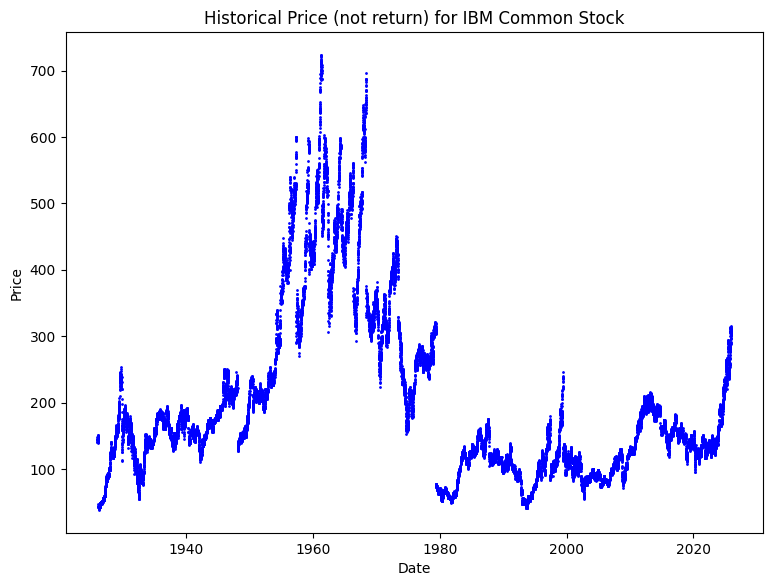

In [ ]:
fig = plt.figure(figsize=(9,6.5))
price = dfx.loc[b_ibm, 'DlyPrc']
date = dfx.loc[b_ibm, 'DlyCalDt']
plt.scatter(date, price , color='b', s=1.00)
plt.title("Historical Price (not return) for IBM Common Stock")
plt.xlabel("Date")
plt.ylabel("Price")
# plt.yscale('log')


### IBM returns with dividends and stock splits

CRSP uses the column 'DlyRet' to describe the return from holding IBM stock for one day. The hypothetical experiment is to buy the stock at yesterday's closing price, collect any cash dividends or additional shares distributed as stock dividends (stock splits), then sell the stock at today's closing price. The return is the change in the value of the investment as a fraction of the amount invested. To implement this, CRSP must add dividends to the return and also add the value received from stock splits.  In addition, other corporate events may occasionally occur (spinoffs, mergers, etc.).

Let's see if we can replicate CRSP's calculation of 'DlyRet' by using the data on stock price, dividends, and stock splits.

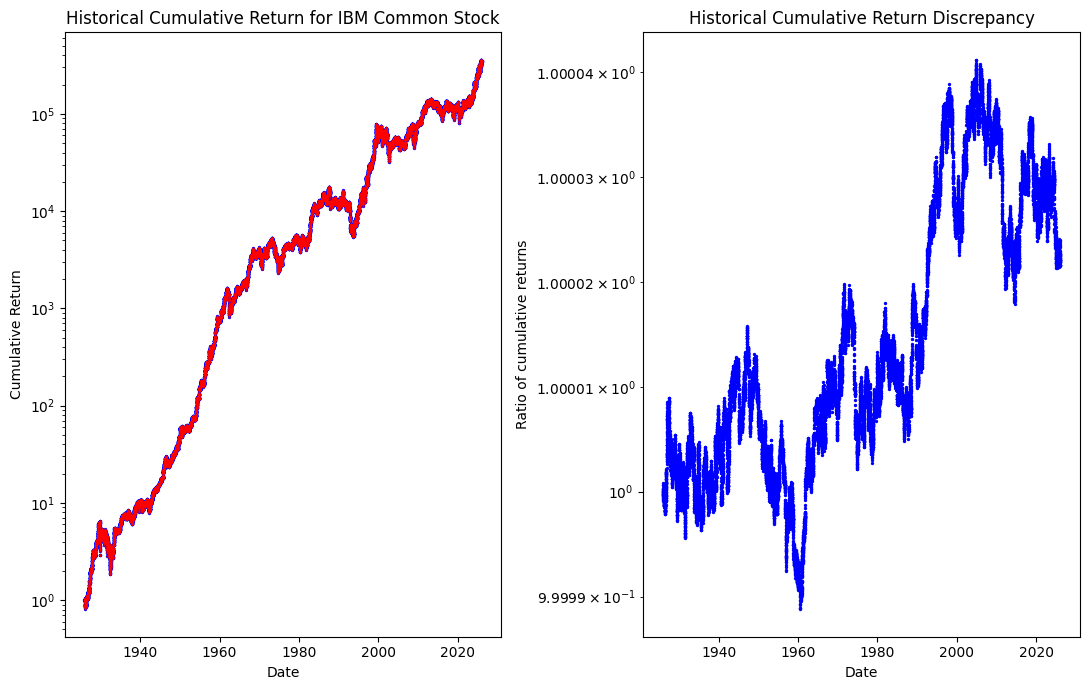

In [ ]:
return_ibm = df_ibm['DlyRet'].fillna(0.0)
gross_return_ibm = 1.00 + return_ibm
cumulative_return_ibm = gross_return_ibm.cumprod()
df_ibm['cumulative_return'] = cumulative_return_ibm

gross_ret_ibm_replicated = ((df_ibm['DlyPrc'] * df_ibm['DlyFacPrc'] + df_ibm['DlyOrdDivAmt']) / df_ibm['DlyPrevPrc']).fillna(1.0)
cum_ret_ibm_replicated =  gross_ret_ibm_replicated.cumprod()

date = df_ibm['DlyCalDt']

fig, ax = plt.subplots(1, 2, figsize=(11, 7))

ax[0].scatter(date, cumulative_return_ibm , color='b', s=2.00)
ax[0].scatter(date, cum_ret_ibm_replicated , color='r', s=0.20)
ax[0].set_title("Historical Cumulative Return for IBM Common Stock")
ax[0].set_xlabel("Date")
ax[0].set_ylabel("Cumulative Return")
ax[0].set_yscale('log')

ax[1].scatter(date, cumulative_return_ibm / cum_ret_ibm_replicated , color='b', s=2.00)
ax[1].set_title("Historical Cumulative Return Discrepancy")
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Ratio of cumulative returns")
ax[1].set_yscale('log')

plt.tight_layout()


As you can see, the replication worked well. The two plots in the left panel sit right on top of each other. Errors appear to be rounding error.  Perhaps we got lucky in that IBM did not have any of the occasional other corporate events which can affect returns.

### More on stock splits

Investors sometimes try to make a distinction between stock splits and stock dividends, even though these are conceptually the same concept.

Companies sometimes give investors extra shares proportional to their ownership of existing shares.  Since this creation of extra shares tends to have no effect on the total value of the company (**market capitalization**), the value of the shares should immediately fall by a proportional amount. We can think of a **stock dividend** as a relatively small number of shares given per 100 shares owned.  We can think of a **stock split** as a large number of shares given per 100 shares owned. The cutoff between a stock dividend and a stock split is purely arbitrary. Some investors use a 2 for 1 stock split as the cutoff (i.e., any stock dividend which gives more than 100 shares per 100 shares owned is considered to be a stock split.)

As we can see from the following cell, IBM has had both small stock dividends and large stock splits. For example, it has had four 2-for-1 splits, one 3-for-1 split, and one 4_for-1 split, which alone should have reduced the price of the stock by a factor of $2^4 * 3 * 4 = 192$ over the years!

What does matter finacially with stock dividends is whether the company acquires the shares distributed to shareholders by creating new shares out of thin air (perfectly acceptable) or by buying back previously issued shares in the market.

In [ ]:
dfx.loc[b_ibm, 'DlyFacPrc'].value_counts().reset_index(drop=False).sort_values('DlyFacPrc')

,DlyFacPrc,count
0,1.000000,26259
11,1.004233,1
6,1.020000,2
2,1.025000,6
10,1.027108,1
7,1.030000,2
13,1.043657,1
1,1.050000,18
3,1.250000,5
5,1.500000,3


Companies also pay cash dividends. Roughtly speaking, dividends tend to be high when a company generates significant cash flow (from a profitable busines) and choose not to invest the cash in new plant and equipment but instead gives the cash to shareholders.

Here is a count of the value of cash dividends paid on different days.  The most common dividend amount is 0.00 because companies typically pay dividends quarerly, not every day.

In [ ]:
dfx.loc[b_ibm, 'DlyOrdDivAmt'].value_counts().reset_index(drop=False).sort_values('DlyOrdDivAmt')

,DlyOrdDivAmt,count
0,0.000000,25901
40,0.120000,3
33,0.130000,4
32,0.140000,4
31,0.150000,4
30,0.160000,4
29,0.180000,4
13,0.200000,7
26,0.220000,4
48,0.240000,1


### Mean Returns

We can measure mean daily returns for IBM stock as follows:

(Note that a **basis point** is defined as one one-hundredth of one percent. Sticklers for financial terminology may argue about whether basis points should have time unites.  Here they do not.)

In [ ]:
mean_return_ibm = df_ibm['DlyRet'].mean()
print(f"{mean_return_ibm=} = {mean_return_ibm * 10**4} basis points per trading day")

mean_return_ibm=np.float64(0.0006009239167649408) = 6.009239167649408 basis points per trading day


### Internal rate of return

The **internal rate of return** (**IRR**) is the hypothetical constant rate of return which gives the same total return as actual random rate of return observed over a given time period.



In [ ]:
num_trading_days_ibm = len(df_ibm)
cum_ret_ibm = df_ibm.loc[df_ibm.index[-1], 'cumulative_return'] / df_ibm.loc[df_ibm.index[0], 'cumulative_return']
irr_factor_ibm = (cum_ret_ibm)**(1 / (num_trading_days_ibm - 1))
irr_ibm = irr_factor_ibm - 1.00


print(f"{num_trading_days_ibm=}")
print(f"{cum_ret_ibm=}")
print(f"{irr_ibm=} = {irr_ibm * 10**4} basis points per trading day")


num_trading_days_ibm=26305
cum_ret_ibm=np.float64(338443.7872352222)
irr_ibm=np.float64(0.00048415431867465664) = 4.841543186746566 basis points per trading day


### Mean return and internal rate of return are different

Note that the mean return and the internal rate of return are different!

The internal rate of return is a **geometric mean**, which is different from an **arithmetic mean**.

This particular issue is a huge source of confusion in finance! We will discuss it more later.

### Standard deviation of returns

In finance, the standard deviation of returns is often called **volatility**.

Later in this course, we will later discuss a slightly different but closely related concept, **log-volatility**, often called **Black-Scholes volatility**.

Let's calculate the mean daily standard deviation of IBM returns over its lifetime:

In [ ]:
std_ibm = df_ibm['DlyRet'].std()
print(f"{std_ibm=} = {std_ibm * 10**2} percent per day = {std_ibm * 10**4} basis points per day")

std_ibm=0.01525703902451936 = 1.525703902451936 percent per day = 152.5703902451936 basis points per day


# Homework Questions

You should answer all of the homework questions below.  They are all straightforward, designed to familiarize you with typical usage of Pandas in finance.

If you are not familiar with Pandas, there will be a learning curve here.  I encourage you to:

1. Look carefully at my sample code above.  Almost every line illustrates usage for later in this course and typical usage for practitioners or researchers.

2. Read the Pandas and Numpy documentation to familiarize yourself with the available functions and their typical syntax.

3. Ask questions using google, AI, or **Stackoverflow**. AI often give exactly the answer you are looking for, which is also closely correlated with Stackoverflow.

If you find yourself running out of time and cannot finish all questions by the due date, try to do the last question.

### Question 1 (Easy)

1.  Which companies were already in existence when CRSP data starts in 1925-12-31?

4. Guess when CRSP started reporting ticker symbols.

5. Point out one additional interesting fact you observe.

In [ ]:
vns = ['PERMCO', 'IssuerNm']

aggs = {'first_date': ('DlyCalDt', 'min'), 'last_date': ('DlyCalDt', 'max')}

df1 = (dfx[vns + ['DlyCalDt']].groupby(vns, dropna=False).agg(**aggs).reset_index(drop=False).sort_values('first_date'))

display(df1.loc[df1['first_date'] == pd.Timestamp('1925-12-31')])

,PERMCO,IssuerNm,first_date,last_date
13,20990,INTERNATIONAL BUSINESS MACHS COR,1925-12-31,2025-12-31
11,20799,GENERAL MOTORS CORP,1925-12-31,2009-06-01


In [ ]:
display(dfx.loc[dfx['Ticker'].notna(), ['DlyCalDt', 'Ticker', 'PERMCO', 'IssuerNm']].sort_values('DlyCalDt').head(20))

print("Earliest date with a reported ticker:", dfx.loc[dfx['Ticker'].notna(), 'DlyCalDt'].min())


,DlyCalDt,Ticker,PERMCO,IssuerNm
46316,1962-07-02,IBM,20990,INTERNATIONAL BUSINESS MACHS COR
20366,1962-07-02,GM,20799,GENERAL MOTORS CORP
46317,1962-07-03,IBM,20990,INTERNATIONAL BUSINESS MACHS COR
20367,1962-07-03,GM,20799,GENERAL MOTORS CORP
46318,1962-07-05,IBM,20990,INTERNATIONAL BUSINESS MACHS COR
20368,1962-07-05,GM,20799,GENERAL MOTORS CORP
46319,1962-07-06,IBM,20990,INTERNATIONAL BUSINESS MACHS COR
20369,1962-07-06,GM,20799,GENERAL MOTORS CORP
46320,1962-07-09,IBM,20990,INTERNATIONAL BUSINESS MACHS COR
20370,1962-07-09,GM,20799,GENERAL MOTORS CORP


Earliest date with a reported ticker: 1962-07-02 00:00:00


In [ ]:
fact = (dfx.groupby(['PERMCO', 'IssuerNm'], dropna=False)['PERMNO'].nunique().reset_index(name='num_permnos').sort_values('num_permnos', ascending=False))

display(fact)


,PERMCO,IssuerNm,num_permnos
11,20799,GENERAL MOTORS CORP,3
14,45483,ALPHABET INC,2
15,45483,GOOGLE INC,2
4,540,BERKSHIRE HATHAWAY INC DEL,2
0,7,APPLE COMPUTER INC,1
3,437,BANKAMERICA CORP (Last Known),1
2,437,BANKAMERICA CORP,1
1,7,APPLE INC,1
5,2367,INTEL CORP,1
8,3151,N C N B CORP,1


The table above shows how many securities are assoicated with each company. Some have multiple, but most have one.

### Question 2 (Easy)

Why does Berkshire Hathaway have more rows of data than Intel (INTC), even though Intel has existed for a longer time?

In [ ]:
aggs = {'num_rows': ('PERMNO', 'count'), 'num_permnos': ('PERMNO', 'nunique'), 'first_date': ('DlyCalDt', 'min'), 'last_date': ('DlyCalDt', 'max')}

df2 = (dfx.groupby(['PERMCO', 'IssuerNm'], dropna=False).agg(**aggs).reset_index(drop=False).sort_values('num_rows', ascending=False))

display(df2.loc[df2['IssuerNm'].str.contains('BERKSHIRE|INTEL', case=False, na=False)])


,PERMCO,IssuerNm,num_rows,num_permnos,first_date,last_date
4,540,BERKSHIRE HATHAWAY INC DEL,19866,2,1976-10-14,2025-12-31
5,2367,INTEL CORP,13374,1,1972-12-14,2025-12-31


Berkshire Hathaway has two permnos associated with it causing it to have more rows even though it has not been a company for as long.

### Question 3 (Easy)

When playing with datasets, it is useful to do mental "reality checks" along the way. Since the data start in 1925 and end in 2025, we might guess the number of rows in the dataset is very approximately

100 years * 250 trading days per year * 10 stocks = 250_000.

How many rows are actually in the dataset? Why is there a big difference between our guess and the actual answer? (This question has a very simple common-sense answer, which can be easily guessed based on common knowledge and  which can also be verified by looking at the data carefully.)



There are mulitple companies who have multiple permnos and also they all joined the market at different times and as such will not always have the full 250000 days. This would create enough of a difference between the estimate vs the real amount.

### Question 4 (Easy) Economics of financial information

Why would an annually updated subscription to financial data (such as CRSP) be much cheaper than a subscription updated daily?

What timeframes for updates to financial data subscriptions are most valuable in the market for financial data?

(Hint: Do not spend much time on this question. Just think about it for a few minutes and make a quick guess. We can discuss further in class.)

Daily data needs constant checking and cleaning. If something goes wrong, it has to be fixed immediately and there are more chances of things going wrong. In yearly data, there is more time to fix mistakes and add changes. The most valuable data is tick data as it is the smallest time stamp and therefore the hardest to collect. However, with it, you can recreate any other data and have the ability to see much smaller changes and trends compared to any other timeframe of data.

### Question 5

Study the documentation for `pd.read_csv(...)`.

Compare the time it takes to read a CSV file and convert object dtypes to datetime or pyarrow[string] with the time it takes to read a saved parquet file.



In [ ]:
t0 = timeit.default_timer()

df_csv = pd.read_csv(file_path_permco, low_memory=False)

date_columns = [vn for vn in df_csv.columns if vn[-2:] == 'Dt']

df_csv[date_columns] = df_csv[date_columns].apply(pd.to_datetime)

string_columns = [vn for vn in df_csv.columns if df_csv[vn].dtype == 'object']

df_csv[string_columns] = df_csv[string_columns].astype('string[pyarrow]')

csv_time = timeit.default_timer() - t0

parquet_file_path_permco = os.path.join(dir_path, 'crsp_hw1_permco.parquet')

df_csv.to_parquet(parquet_file_path_permco, engine='pyarrow')

t0 = timeit.default_timer()

df_parquet = pd.read_parquet(parquet_file_path_permco, engine='pyarrow', dtype_backend='pyarrow')

parquet_time = timeit.default_timer() - t0

print(f"CSV read and conversion time = {csv_time} seconds")
print(f"Parquet read time = {parquet_time} seconds")
print(f"CSV / Parquet = {csv_time / parquet_time}")


CSV read and conversion time = 5.54602251999998 seconds
Parquet read time = 0.39947166700000025 seconds
CSV / Parquet = 13.883393937923453


### Question 6

Create a table which describes in a nice way the exchange each company trades on ('N' for NYSE and 'Q' for Nasdaq)? Did any of the companies change their primary (listing) exchange?

When a company is delisted, how does this show up in the CRSP data?



In [ ]:
vns = ['PERMCO', 'IssuerNm', 'PrimaryExch']

aggs = {'first_date': ('DlyCalDt', 'min'), 'last_date': ('DlyCalDt', 'max'), 'num_days': ('DlyCalDt', 'count')}

df6 = (dfx[vns + ['DlyCalDt']].groupby(vns, dropna=False).agg(**aggs).reset_index(drop=False).sort_values(['IssuerNm', 'first_date']))

display(df6)


,PERMCO,IssuerNm,PrimaryExch,first_date,last_date,num_days
18,45483,ALPHABET INC,Q,2015-10-05,2025-12-31,5152
0,7,APPLE COMPUTER INC,Q,1980-12-12,2007-01-10,6581
1,7,APPLE INC,Q,2007-01-11,2025-12-31,4774
8,3151,BANK OF AMERICA CORP,N,1999-04-29,2025-12-31,6711
3,437,BANKAMERICA CORP,Q,1972-12-14,1976-06-25,891
2,437,BANKAMERICA CORP,N,1976-06-28,1998-09-30,5627
4,437,BANKAMERICA CORP (Last Known),X,1998-10-01,1998-10-01,1
9,3151,BANKAMERICA CORP NEW,N,1998-10-01,1999-04-28,144
6,540,BERKSHIRE HATHAWAY INC DEL,Q,1976-10-14,1988-11-28,3064
5,540,BERKSHIRE HATHAWAY INC DEL,N,1988-11-29,2025-12-31,16802


In [ ]:
df6c = (dfx.groupby(['PERMCO', 'IssuerNm'], dropna=False)['PrimaryExch'].nunique().reset_index(name='num_exchanges'))

display(df6c.loc[df6c['num_exchanges'] > 1])


,PERMCO,IssuerNm,num_exchanges
2,437,BANKAMERICA CORP,2
4,540,BERKSHIRE HATHAWAY INC DEL,2
8,3151,N C N B CORP,2
11,20799,GENERAL MOTORS CORP,2


In [ ]:
print(dfx['DlyDelFlg'].value_counts(dropna=False))

display(dfx.loc[dfx['DlyDelFlg'] != 'N',['PERMCO', 'PERMNO', 'IssuerNm', 'DlyCalDt', 'DlyDelFlg', 'DelActionType', 'DelStatusType', 'DelReasonType']])


DlyDelFlg
N    149922
Y         4
Name: count, dtype: int64


,PERMCO,PERMNO,IssuerNm,DlyCalDt,DlyDelFlg,DelActionType,DelStatusType,DelReasonType
32191,20799,12079,GENERAL MOTORS CORP (Last Known),2009-06-02,Y,NaN,NaN,NaN
98958,437,58827,BANKAMERICA CORP (Last Known),1998-10-01,Y,NaN,NaN,NaN
128647,20799,66931,GENERAL MOTORS CORP,1996-06-10,Y,NaN,NaN,NaN
133186,20799,68451,GENERAL MOTORS CORP,2003-12-23,Y,NaN,NaN,NaN


### Question 7

Create a nice table showing the number of times each company has paid an ordinary (cash) dividend. Did any of the companies never pay an ordinary dividend?





In [ ]:
dfx['paid_dividend'] = (dfx['DlyOrdDivAmt'] > 0)

aggs = {'num_dividends': ('paid_dividend', 'sum')}

df7 = (dfx.groupby(['PERMCO', 'IssuerNm'],dropna=False).agg(**aggs).reset_index(drop=False).sort_values('num_dividends', ascending=False))

display(df7)


,PERMCO,IssuerNm,num_dividends
11,20799,GENERAL MOTORS CORP,458
13,20990,INTERNATIONAL BUSINESS MACHS COR,404
5,2367,INTEL CORP,129
6,3151,BANK OF AMERICA CORP,107
2,437,BANKAMERICA CORP,91
10,8048,MICROSOFT CORP,89
8,3151,N C N B CORP,76
1,7,APPLE INC,54
18,53554,GENERAL MOTORS CO,39
0,7,APPLE COMPUTER INC,35


### Question 8

If you bought 100 shares of stock for each company on the inital date it show up in the CRSP data and held the shares until the last day which shows up (e.g., 2025-12-31), how many shares would you own on the last day if you did not reinvest dividends into the company's stock but did keep extra shares received from stock dividend (stock splits)?

**Extra Credit**: How many shares of each company's stock would you own on the last day if you invested every dividend back into the company's stock on the day it was received and did not have to pay taxes on the dividends. (Hint: This might be a case where a slow, inefficient Python loop appears to be needed. Can you avoid the loop by using Pandas or Numpy functions?)



In [ ]:
df8 = dfx.sort_values(['PERMNO', 'DlyCalDt']).copy()

df8['share_factor'] = (df8.groupby('PERMNO')['DlyFacPrc'].cumprod())

df8['shares_from_100'] = (100.0 * df8['share_factor'])

aggs = {'first_date': ('DlyCalDt', 'first'), 'last_date': ('DlyCalDt', 'last'), 'ending_shares': ('shares_from_100', 'last')}

df8_answer = (df8.groupby(['PERMCO', 'PERMNO', 'IssuerNm'], dropna=False).agg(**aggs).reset_index(drop=False))

display(df8_answer)


,PERMCO,PERMNO,IssuerNm,first_date,last_date,ending_shares
0,7,14593,APPLE COMPUTER INC,1980-12-12,2007-01-10,8.000000e+02
1,7,14593,APPLE INC,2007-01-11,2025-12-31,2.240000e+04
2,437,58827,BANKAMERICA CORP,1972-12-14,1998-09-30,4.000000e+02
3,437,58827,BANKAMERICA CORP (Last Known),1998-10-01,1998-10-01,4.000000e+02
4,540,17778,BERKSHIRE HATHAWAY INC DEL,1976-10-14,2025-12-31,1.000000e+02
5,540,83443,BERKSHIRE HATHAWAY INC DEL,1996-05-09,2025-12-31,5.000000e+03
6,2367,59328,INTEL CORP,1972-12-14,2025-12-31,1.215000e+05
7,3151,59408,BANK OF AMERICA CORP,1999-04-29,2025-12-31,8.000000e+02
8,3151,59408,BANKAMERICA CORP NEW,1998-10-01,1999-04-28,4.000000e+02
9,3151,59408,N C N B CORP,1972-12-14,1991-12-31,2.000000e+02


In [ ]:
df8e = dfx.sort_values(['PERMNO', 'DlyCalDt']).copy()

df8e['gross_return'] = (1.0 + df8e['DlyRet'].fillna(0.0))

df8e['cumulative_return'] = (df8e.groupby('PERMNO')['gross_return'].cumprod())

df8e['first_price'] = (df8e.groupby('PERMNO')['DlyPrc'].transform('first'))

df8e['investment_value'] = (100.0 * df8e['first_price'] * df8e['cumulative_return'])

df8e['shares_with_reinvestment'] = (df8e['investment_value'] / df8e['DlyPrc'])

aggs = {'first_date': ('DlyCalDt', 'first'), 'last_date': ('DlyCalDt', 'last'), 'ending_shares_with_reinvestment': ('shares_with_reinvestment', 'last')}

df8e_answer = (df8e.groupby(['PERMCO', 'PERMNO', 'IssuerNm'], dropna=False).agg(**aggs).reset_index(drop=False))

display(df8e_answer)


,PERMCO,PERMNO,IssuerNm,first_date,last_date,ending_shares_with_reinvestment
0,7,14593,APPLE COMPUTER INC,1980-12-12,2007-01-10,8.765515e+02
1,7,14593,APPLE INC,2007-01-11,2025-12-31,2.922752e+04
2,437,58827,BANKAMERICA CORP,1972-12-14,1998-09-30,1.039704e+03
3,437,58827,BANKAMERICA CORP (Last Known),1998-10-01,1998-10-01,inf
4,540,17778,BERKSHIRE HATHAWAY INC DEL,1976-10-14,2025-12-31,9.999667e+01
5,540,83443,BERKSHIRE HATHAWAY INC DEL,1996-05-09,2025-12-31,4.999901e+03
6,2367,59328,INTEL CORP,1972-12-14,2025-12-31,2.162597e+05
7,3151,59408,BANK OF AMERICA CORP,1999-04-29,2025-12-31,4.363630e+03
8,3151,59408,BANKAMERICA CORP NEW,1998-10-01,1999-04-28,1.097540e+03
9,3151,59408,N C N B CORP,1972-12-14,1991-12-31,4.409597e+02


### Question 9

Create a nice table listing each security's PERMNO and PERMCO, the security's name on the last day,  the first and last dates, the value to which one dollar grows (if all dividends are reinvested back into the company), the dollar market capitalization of the company on the last day (in dollars), the daily volatility (in basis points), the daily mean return (in basis points), and the daily internal rate of return (in basis points).

Hint: Use `groupby(...).agg(...)`. In addition to 'mean', 'sum', and 'std', there are also some other useful aggregation functions (**reductions**), such as 'first' and 'last'.

In [ ]:
df9 = dfx.sort_values(['PERMNO', 'DlyCalDt']).copy()

df9['gross_return'] = (1.0 + df9['DlyRet'].fillna(0.0))

df9['cumulative_return'] = (df9.groupby('PERMNO')['gross_return'].cumprod())

aggs = {'SecurityNm': ('SecurityNm', 'last'), 'first_date': ('DlyCalDt', 'first'), 'last_date': ('DlyCalDt', 'last'), 'dollar_growth': ('cumulative_return', 'last'), 'market_cap': ('DlyCap', 'last'), 'mean_return': ('DlyRet', 'mean'), 'volatility': ('DlyRet', 'std'), 'num_days': ('DlyCalDt', 'count')}

df9_answer = (df9.groupby(['PERMNO', 'PERMCO'], dropna=False).agg(**aggs).reset_index(drop=False))

df9_answer['market_cap_dollars'] = (df9_answer['market_cap'] * 1000.0)

df9_answer['mean_return_bps'] = (df9_answer['mean_return'] * 10**4)

df9_answer['volatility_bps'] = (df9_answer['volatility'] * 10**4)

df9_answer['irr'] = (df9_answer['dollar_growth']** (1.0 / (df9_answer['num_days'] - 1)) - 1.0)

df9_answer['irr_bps'] = (df9_answer['irr'] * 10**4)

display(
    df9_answer[
        ['PERMNO', 'PERMCO', 'SecurityNm', 'first_date', 'last_date', 'dollar_growth', 'market_cap_dollars', 'volatility_bps', 'mean_return_bps', 'irr_bps']])

,PERMNO,PERMCO,SecurityNm,first_date,last_date,dollar_growth,market_cap_dollars,volatility_bps,mean_return_bps,irr_bps
0,10107,8048,MICROSOFT CORP; COM NONE; CONS,1986-03-13,2025-12-31,8261.473564,3.594447e+12,208.924898,11.186803,8.997323
1,12079,20799,GENERAL MOTORS CORP (LAST KNOWN); COM NONE; CONS,1925-12-31,2009-06-02,68.080940,4.579215e+08,209.594430,4.108198,1.904742
2,12369,53554,GENERAL MOTORS CO; COM NONE; CONS,2010-11-18,2025-12-31,3.188176,7.586026e+10,216.970697,5.400800,3.050844
3,12490,20990,INTERNATIONAL BUSINESS MACHS COR; COM NONE; CONS,1925-12-31,2025-12-31,338443.787235,2.768779e+11,152.570390,6.009239,4.841543
4,13407,54084,META PLATFORMS INC; COM A; CONS,2012-05-18,2025-12-31,17.384917,1.437603e+12,250.187377,11.469065,8.343441
5,14542,45483,ALPHABET INC; COM C; CONS,2014-04-03,2025-12-31,11.129614,1.696717e+12,178.891284,9.755487,8.160435
6,14593,7,APPLE INC; COM NONE; CONS,1980-12-12,2025-12-31,2757.758967,4.017099e+12,276.319099,10.860576,6.979864
7,17778,540,BERKSHIRE HATHAWAY INC DEL; COM A; CONS,1976-10-14,2025-12-31,11018.611678,3.947604e+11,149.431893,8.647356,7.505710
8,58827,437,BANKAMERICA CORP (LAST KNOWN); COM NONE; CONS,1972-12-14,1998-10-01,13.529292,4.117156e+10,200.593272,6.005288,3.997204
9,59328,2367,INTEL CORP; COM NONE; CONS,1972-12-14,2025-12-31,1564.702252,1.760130e+11,269.194564,9.143455,5.501738


### Question 10

Create 12 different plots on a 4 by 3 grid showing the cumulative return of one dollar invested in each company's stock.

Create on big plot showing the cumulative return on all of the securities (PERMNO) over time. (This plot will have different beginning and ending dates for varous companies.)

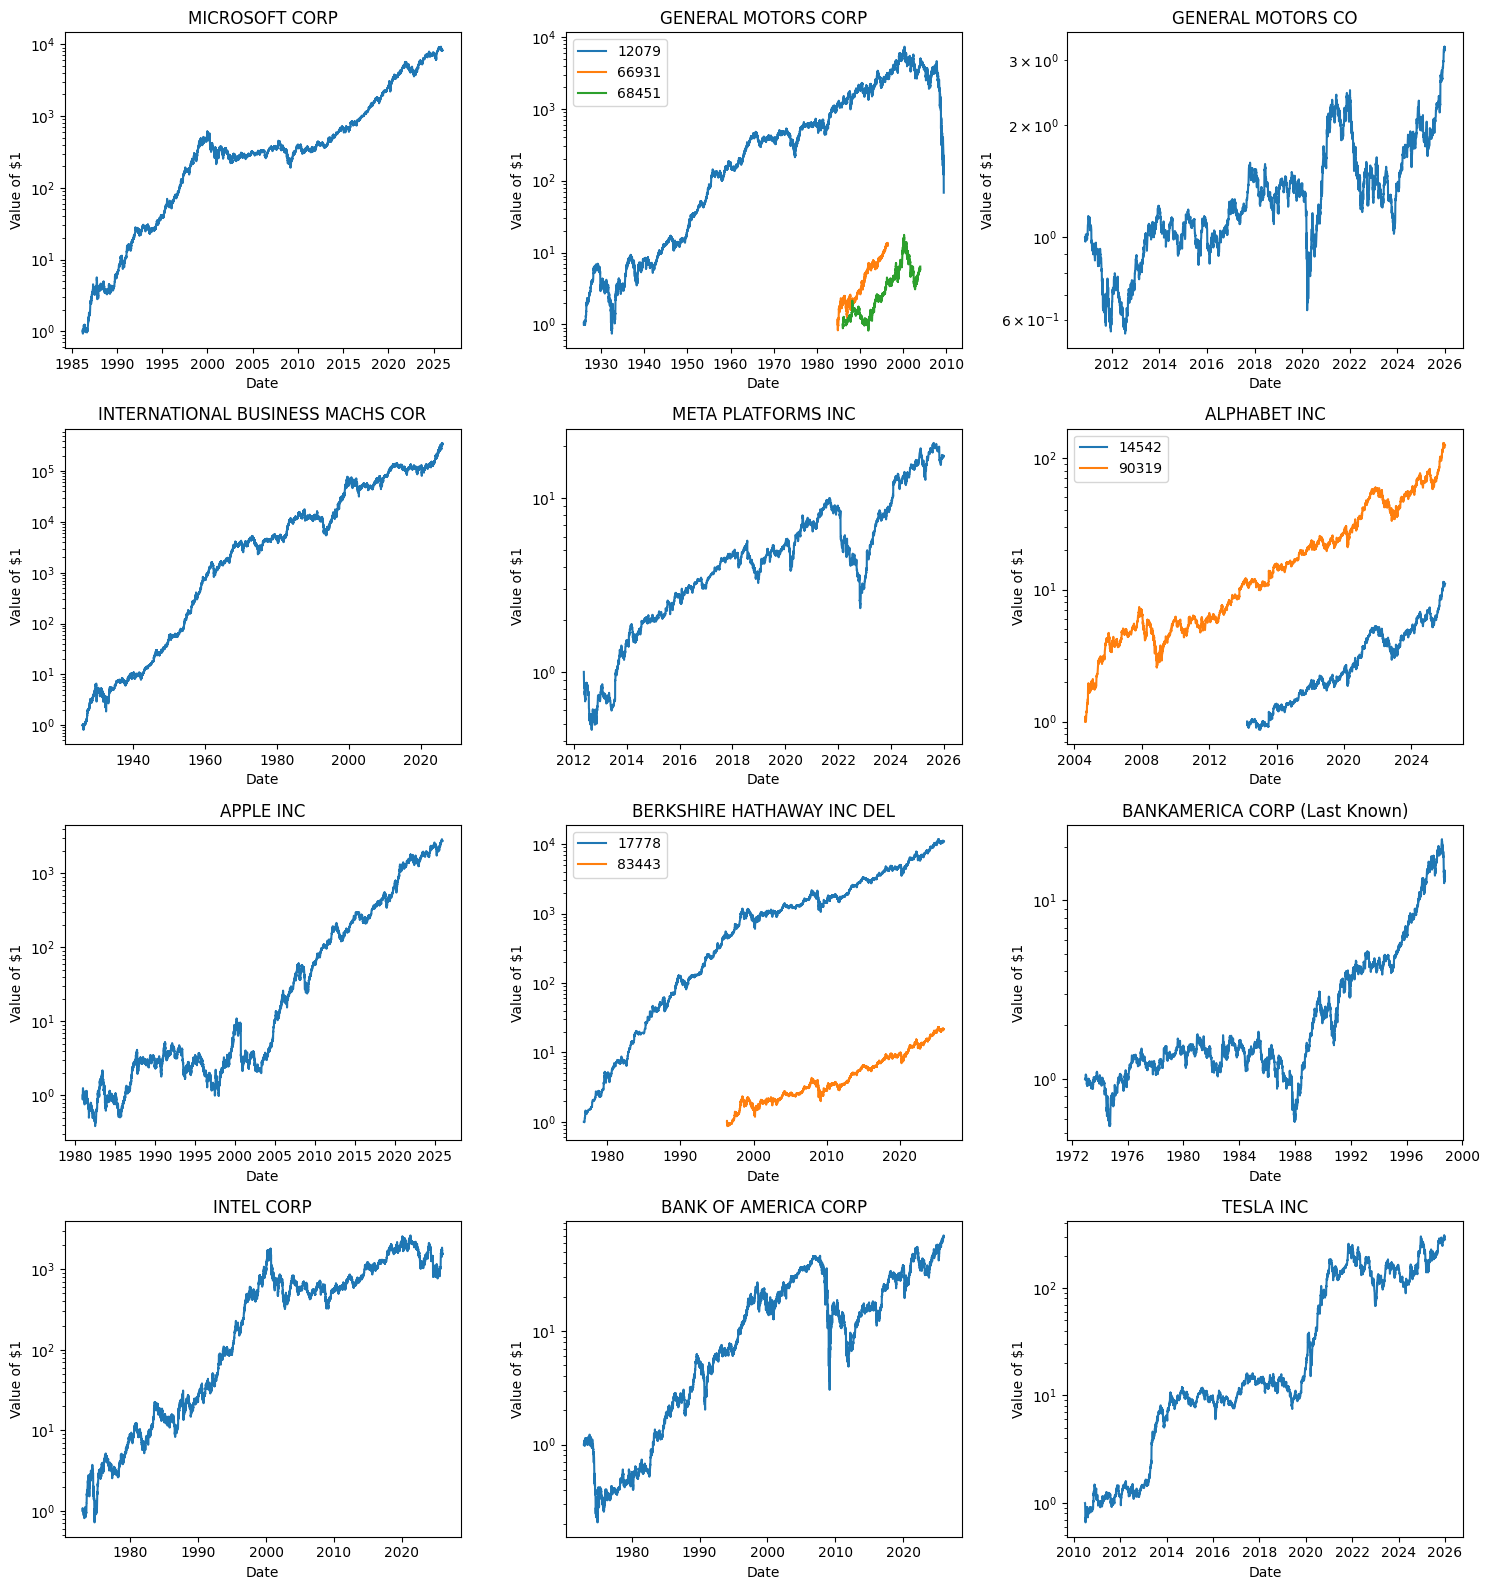

In [ ]:
df10 = dfx.sort_values(['PERMNO', 'DlyCalDt']).copy()

df10['gross_return'] = (1.0 + df10['DlyRet'].fillna(0.0))

df10['cumulative_return'] = (df10.groupby('PERMNO')['gross_return'].cumprod())

permcos = df10['PERMCO'].drop_duplicates().to_list()

fig, axs = plt.subplots(4, 3, figsize=(15, 16))

axs = axs.flatten()

for i, permco in enumerate(permcos):

    b = df10['PERMCO'] == permco
    df_temp = df10.loc[b]

    for permno in df_temp['PERMNO'].drop_duplicates():

        b_permno = df_temp['PERMNO'] == permno

        axs[i].plot(df_temp.loc[b_permno, 'DlyCalDt'], df_temp.loc[b_permno, 'cumulative_return'], label=str(permno))

    company_name = (df_temp['IssuerNm'].dropna().iloc[-1])

    axs[i].set_title(company_name)
    axs[i].set_yscale('log')
    axs[i].set_xlabel('Date')
    axs[i].set_ylabel('Value of $1')

    if df_temp['PERMNO'].nunique() > 1:
        axs[i].legend()

fig.tight_layout()

plt.show()


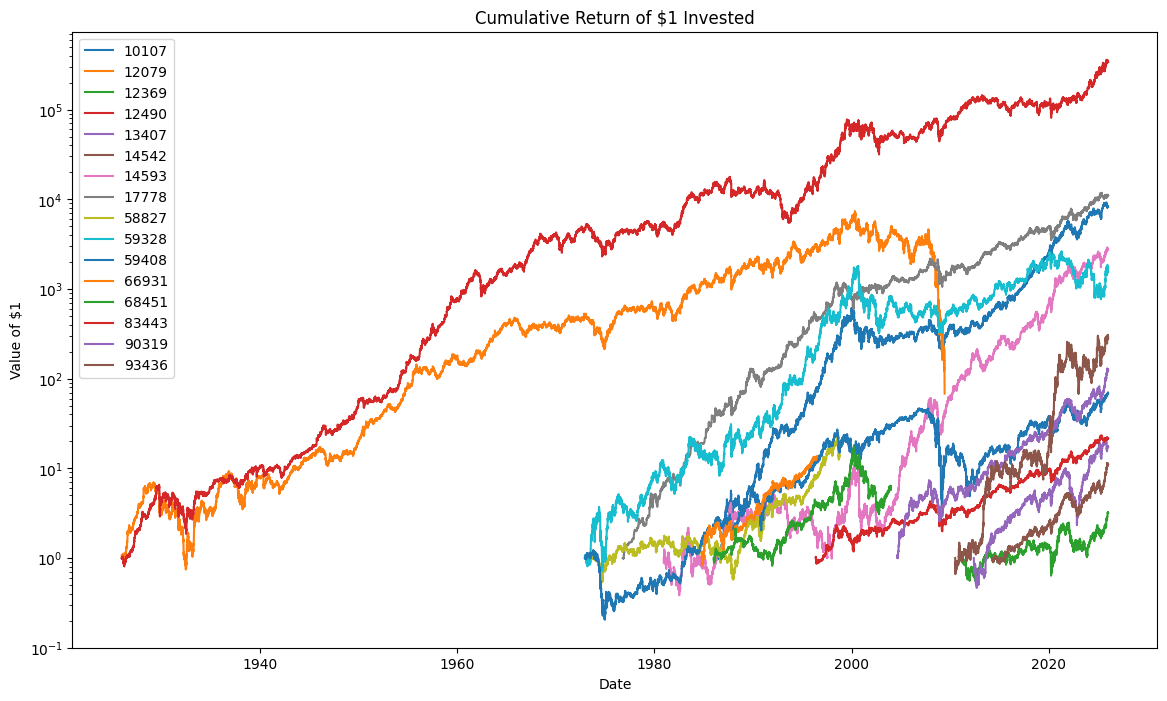

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))

for permno in df10['PERMNO'].drop_duplicates():

    b = df10['PERMNO'] == permno
    df_temp = df10.loc[b]

    ax.plot(df_temp['DlyCalDt'], df_temp['cumulative_return'], label=str(permno))

ax.set_yscale('log')
ax.set_xlabel('Date')
ax.set_ylabel('Value of $1')
ax.set_title('Cumulative Return of $1 Invested')

ax.legend()

plt.show()


### Extra Credit

Play around with some of the other columns of the dataset. Be prepared to tell the class something interesting that you learn, either about CRSP data or about the companies themselves.


In [ ]:
aggs = {'mean_return': ('DlyRet', 'mean'), 'volatility': ('DlyRet', 'std')}

dfe = (dfx.groupby(['PERMCO', 'PERMNO', 'IssuerNm'], dropna=False).agg(**aggs).reset_index(drop=False))

dfe['mean_return_bps'] = (dfe['mean_return'] * 10**4)

dfe['volatility_bps'] = (dfe['volatility'] * 10**4)

dfe['return_to_volatility'] = (dfe['mean_return'] / dfe['volatility'])

display(dfe[['PERMCO', 'PERMNO', 'IssuerNm', 'mean_return_bps', 'volatility_bps', 'return_to_volatility']].sort_values('return_to_volatility', ascending=False))

,PERMCO,PERMNO,IssuerNm,mean_return_bps,volatility_bps,return_to_volatility
8,3151,59408,BANKAMERICA CORP NEW,27.417500,293.292640,0.093482
22,53453,93436,TESLA MOTORS INC,19.555518,330.799984,0.059116
17,45483,14542,ALPHABET INC,10.605093,180.529819,0.058744
1,7,14593,APPLE INC,11.458645,197.341533,0.058065
4,540,17778,BERKSHIRE HATHAWAY INC DEL,8.647356,149.431893,0.057868
19,45483,90319,ALPHABET INC,10.417807,180.752696,0.057636
21,53453,93436,TESLA INC,22.169232,386.808174,0.057313
20,45483,90319,GOOGLE INC,11.240904,204.011492,0.055099
14,20799,66931,GENERAL MOTORS CORP,10.797535,198.651116,0.054354
11,8048,10107,MICROSOFT CORP,11.186803,208.924898,0.053545


I compared the average daily return and volatility of the stocks to see which ones had the best gains while remaining the most stable. I divided the average return by volatility to get a ratio that could act as a comparison to other securities.

In [ ]:
elapsed_time = timeit.default_timer() - t_begin
print(f"done: {elapsed_time=}")

done: elapsed_time=45.692079172999996
